In [1]:
import pandas as pd
import numpy as np
import plotly.express as px
from scipy.stats import ttest_ind
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
from statsmodels.stats.anova import AnovaRM
from scipy.stats import mannwhitneyu, norm
from scipy.stats import wilcoxon


In [2]:
dfs={}
relevent_subIds = {}
results_main={}
results_additional={}
relevent_subNums={}
COHS = {}
timeDf = {}

In [3]:
relevant_columns = ['correctFirstRedPress',
       'correctFirstBluePress', 'incorrectRedPress', 'incorrectBluePress',
       'redChoice', 'blueChoice','correctFirstRedPressSpeeds',
       'correctFirstBluePressSpeeds', 'incorrectRedPressSpeeds',
       'incorrectBluePressSpeeds', 'redChoiceSpeeds', 'blueChoiceSpeeds',
       'correctFirstRedPressStar',
       'correctFirstBluePressStar', 'incorrectRedPressStar',
       'incorrectBluePressStar', 'redChoiceStar', 'blueChoiceStar',
       'allStars', 'howManyStars', 'correctFirstRedPressDevtest', 'correctFirstBluePressDevtest',
       'incorrectRedPressDevtest', 'incorrectBluePressDevtest', 'redChoiceDev',
       'blueChoiceDev', 'devColorInput', 'expDaysDate']

In [4]:
info_table = pd.read_csv(r'/Users/maya/Library/Mobile Documents/com~apple~CloudDocs/Documents/App/results/pilot 5/subjects_info - sheet1.csv')
relevent_subIds[12] = info_table[(info_table.Experiment=='ST_DevR_Mar2024')&(info_table['isExperimentDone?']==1)].WorkerId
relevent_subIds[14] = info_table[(info_table.Experiment=='ET_DevR_Mar24')&(info_table['isExperimentDone?']==1)].WorkerId

In [5]:
for i in range(12, 15):
    if i == 13:
        continue
    df = pd.read_json(rf'/Users/maya/Library/Mobile Documents/com~apple~CloudDocs/Documents/App/results/pilot 5/results_{i}.json')
    dfs[i] = df

In [6]:
import pandas as pd
import numpy as np
import copy

def get_corrected_presses(row, correct_col, choice_col):
    correct_presses = row[correct_col]
    choices = row[choice_col]

    # Ensure values are lists, otherwise return NaN
    if not isinstance(correct_presses, list) or not isinstance(choices, list):
        return np.nan
    
    corrected = []
    for choice in choices:
        valid_presses = [p for p in correct_presses if p <= choice + 1000 and p > choice]
        if len(valid_presses) > 0:
            corrected.append(valid_presses[0])  # Take the first valid press
            
    return corrected if len(corrected) > 0 else np.nan

def correct_first_press(dfs):
    """
    Fix incorrect first press data by ensuring it is the first press within 1000ms of a choice.
    """
    corrected_dfs = dict()
    
    # Define column pairs to process
    column_pairs = [
        ("correctFirstRedPress", "redChoice"),
        ("correctFirstBluePress", "blueChoice"),
        ("correctFirstRedPressSpeeds", "redChoiceSpeeds"),
        ("correctFirstBluePressSpeeds", "blueChoiceSpeeds"),
        ("correctFirstRedPressStar", "redChoiceStar"),
        ("correctFirstBluePressStar", "blueChoiceStar"),
        ("correctFirstRedPressDevtest", "redChoiceDev"),
        ("correctFirstBluePressDevtest", "blueChoiceDev")
    ]

    for i, df in dfs.items():
        tmp = copy.deepcopy(df)
        for correct_col, choice_col in column_pairs:
            if correct_col in df.columns and choice_col in df.columns:
                # Apply the correction
                tmp[correct_col] = tmp.apply(get_corrected_presses, axis=1, args=(correct_col, choice_col))
        corrected_dfs[i] = tmp
    
    return corrected_dfs

In [7]:
dfs_new = correct_first_press(dfs)
del dfs
dfs = copy.deepcopy(dfs_new)
del dfs_new

In [8]:
for i in range(12, 15):
    if i==13:
        continue
    df = dfs[i]
    results_main[i] = df[df.subId.isin(relevent_subIds[i])]\
    .set_index(['subId',df[df.subId.isin(relevent_subIds[i])].createdAt.str[:10]])[relevant_columns]\
    .apply(lambda row: [len(x) if isinstance(x,list) else 0 for x in row], axis=1, result_type='expand')\
    .rename(columns={i: col for i, col in enumerate(relevant_columns)})\
    .reset_index().groupby(['subId','createdAt']).sum()\
    .drop(columns=['howManyStars', 'expDaysDate'])
    additional_columns = df[df.subId.isin(relevent_subIds[i])].set_index('subId')['howManyStars']
    results_additional[i] = pd.Series({subID: sum(int(v) for v in vals) if len(vals)>0 else 0 for subID, vals in additional_columns.dropna().items()})

In [9]:
# Assuming df is your DataFrame with "subId" and "createdAt" as index and 6 columns
# Replace df with your DataFrame name

# Count the number of entries for each "subId"
entry_counts_14 = results_main[14].groupby('subId').size()

# Assuming df is your DataFrame with "subId" and "createdAt" as index and 7 columns
# Replace df with your DataFrame name

# Define a function to perform the calculation for the specified condition
def calculate(group):
    # Initialize count variable
    count = 0
    # Iterate through rows until the condition is met
    for index, row in group.iterrows():
        # Check if the value in the 7th column (let's assume it's named 'column7') is not equal to 0
        if row['correctFirstRedPressSpeeds'] != 0:
            break
        # Increment count if the condition is still met
        count += 1
        # Stop after 10 entries
        if count == 10:
            break
    # Calculate the sum of columns 1-4 and divide by the sum of columns 5+6 for the selected rows
    calculation = group.iloc[:count, :4].sum(axis=1) / group.iloc[:count, 4:6].sum(axis=1)
    # Count how many calculations are under 0.75
    count_under_075 = (calculation < 0.75).sum()
    return count_under_075

# Group by 'subId' and apply the calculate function
calculations_14 = results_main[14].groupby('subId').apply(calculate)
result_14 = pd.DataFrame({'entry_count': entry_counts_14, 'calculation': calculations_14})

print(result_14)


                          entry_count  calculation
subId                                             
6645c9cfd2c8fb647d0af388           19            0
6645c9cfd2c8fb647d0af389           19            1
6645c9cfd2c8fb647d0af38a           19            0
6645c9cfd2c8fb647d0af38b           19            0
6645c9cfd2c8fb647d0af38c           19            0
6645c9cfd2c8fb647d0af38d           19            0
6645c9cfd2c8fb647d0af38f           18            0
6645c9cfd2c8fb647d0af390           19            3
6645c9cfd2c8fb647d0af394           17            0
6645c9cfd2c8fb647d0af395           18            0
6645c9cfd2c8fb647d0af397           19            0
6645c9cfd2c8fb647d0af398           19            1
6645c9cfd2c8fb647d0af39a           19            0
6645c9cfd2c8fb647d0af39b           19            0
6645c9cfd2c8fb647d0af39e           18            0
6649ae29d2c8fb647d0af3fc           19            0
6649b980d2c8fb647d0af409           19            0


### Check dev color answer 

In [10]:
# dfs[14][dfs[14]['subId'].isin(relevent_subIds[14].dropna())].set_index('subId').devColorInput.dropna()
dfs[12][dfs[12]['subId'].isin(relevent_subIds[12].dropna())].set_index('subId').devColorInput.dropna()

subId
6645cb96d2c8fb647d0af3aa    [blue]
6645cb96d2c8fb647d0af3a5    [blue]
6645cb96d2c8fb647d0af3af    [blue]
6645cb96d2c8fb647d0af3ad    [blue]
6645cb96d2c8fb647d0af3a1    [blue]
6645cb96d2c8fb647d0af3a4    [blue]
6645cb96d2c8fb647d0af3a9    [blue]
6645cb96d2c8fb647d0af3b0    [blue]
6645cb96d2c8fb647d0af3a7     [red]
6645cb96d2c8fb647d0af3a2    [blue]
Name: devColorInput, dtype: object

In [11]:
def return_first_value(x):
    if len(x)==0:
        return np.nan
    return x[0]

In [12]:
# Create a function to filter elements in the list that are greater than 180,000 milliseconds
def filter_list(lst):
    if len([item for item in lst if isinstance(item, int) and item > 180000])==0:
           return np.nan
    return len([item for item in lst if isinstance(item, int) and item > 180000])

def filter_list_pilot5(lst):
    if len([item for item in lst if isinstance(item, int) and item > 120000])==0:
           return np.nan
    return len([item for item in lst if isinstance(item, int) and item > 120000])


def fix_subId(group):
    if len(group)<2:
        return
    if group['subId'].iloc[0] in ['65eb0482d2c8fb647d0aefca','65eb0482d2c8fb647d0aefd1']:#,'64f1e7cad2c8fb647d0add4f','64f41b2cd2c8fb647d0adda5']:
        return group.iloc[-4]  # Return the -4th row for the specific 'subId'
    else:
        return group.iloc[-3]  # Return the -3rd row for other 'subIds'



def filter_correct_presses(presses, choices):
    if not isinstance(presses, list) or not isinstance(choices, list):
        return np.nan  # Ensure only lists are processed
    
    # Step 1: Keep only values > 120000 in presses
    valid_presses = [p for p in presses if p > 120000]
    
    # Step 2: Further filter those values based on the choices condition
    filtered_presses = [p for p in valid_presses if any(p <= c + 1000 for c in choices)]
    
    return len(filtered_presses) if filtered_presses else np.nan  # Return count or NaN


##### check to see that all subs has data

In [13]:
find_last_pressesBlue14 = dfs[14][dfs[14]['subId'].isin(relevent_subIds[14])]\
.set_index(['subId',dfs[14][dfs[14].subId.isin(relevent_subIds[14])].createdAt.str[:10]]).correctFirstBluePress.dropna().reset_index()
find_last_pressesBlue14 = find_last_pressesBlue14[find_last_pressesBlue14['correctFirstBluePress'].apply(lambda x: isinstance(x, list) and len(x) > 0)]
find_last_pressesBlue14['correctFirstBluePress'] = find_last_pressesBlue14['correctFirstBluePress'].apply(filter_list_pilot5).dropna()
find_last_pressesBlue14.sort_values(by='createdAt', ascending=True, inplace=True)
find_last_pressesBlue14 = find_last_pressesBlue14.groupby(['subId', 'createdAt']).first().reset_index()
find_last_pressesBlue14 = find_last_pressesBlue14.groupby('subId').apply(fix_subId)


In [14]:
find_last_choiceBlue14 = dfs[14][dfs[14]['subId'].isin(relevent_subIds[14])]\
.set_index(['subId',dfs[14][dfs[14].subId.isin(relevent_subIds[14])].createdAt.str[:10]]).blueChoice.dropna().reset_index()
find_last_choiceBlue14 = find_last_choiceBlue14[find_last_choiceBlue14['blueChoice'].apply(lambda x: isinstance(x, list) and len(x) > 0)]
find_last_choiceBlue14['blueChoice'] = find_last_choiceBlue14['blueChoice'].apply(filter_list_pilot5).dropna()
find_last_choiceBlue14.sort_values(by='createdAt', ascending=True, inplace=True)
find_last_choiceBlue14 = find_last_choiceBlue14.groupby(['subId', 'createdAt']).first().reset_index()
find_last_choiceBlue14 = find_last_choiceBlue14.groupby('subId').apply(fix_subId)

### Extract data from ET groups for last 2 minuts of the game before the tests:

In [15]:
# Let's say the column containing the lists of time stamps is called "correctFirstBluePress"
# Filter dfs[11] based on 'subId'
find_last_pressesBlue14 = dfs[14][dfs[14]['subId'].isin(relevent_subIds[14])]\
.set_index(['subId',dfs[14][dfs[14].subId.isin(relevent_subIds[14])].createdAt.str[:10]]).correctFirstBluePress.dropna().reset_index()

find_last_pressesRed14 = dfs[14][dfs[14]['subId'].isin(relevent_subIds[14])]\
.set_index(['subId',dfs[14][dfs[14].subId.isin(relevent_subIds[14])].createdAt.str[:10]]).correctFirstRedPress.dropna().reset_index()

find_last_choiceBlue14 = dfs[14][dfs[14]['subId'].isin(relevent_subIds[14])]\
.set_index(['subId',dfs[14][dfs[14].subId.isin(relevent_subIds[14])].createdAt.str[:10]]).blueChoice.dropna().reset_index()

find_last_choiceRed14 = dfs[14][dfs[14]['subId'].isin(relevent_subIds[14])]\
.set_index(['subId',dfs[14][dfs[14].subId.isin(relevent_subIds[14])].createdAt.str[:10]]).redChoice.dropna().reset_index()

# Drop rows where 'correctFirstBluePress' is an empty list
find_last_pressesBlue14 = find_last_pressesBlue14[find_last_pressesBlue14['correctFirstBluePress'].apply(lambda x: isinstance(x, list) and len(x) > 0)]
find_last_pressesRed14 = find_last_pressesRed14[find_last_pressesRed14['correctFirstRedPress'].apply(lambda x: isinstance(x, list) and len(x) > 0)]
find_last_choiceBlue14 = find_last_choiceBlue14[find_last_choiceBlue14['blueChoice'].apply(lambda x: isinstance(x, list) and len(x) > 0)]
find_last_choiceRed14 = find_last_choiceRed14[find_last_choiceRed14['redChoice'].apply(lambda x: isinstance(x, list) and len(x) > 0)]


# Apply the filtering function to 'correctFirstBluePress' list
find_last_pressesBlue14['correctFirstBluePress'] = find_last_pressesBlue14['correctFirstBluePress'].apply(filter_list).dropna()
find_last_pressesRed14['correctFirstRedPress'] = find_last_pressesRed14['correctFirstRedPress'].apply(filter_list).dropna()
find_last_choiceBlue14['blueChoice'] = find_last_choiceBlue14['blueChoice'].apply(filter_list).dropna()
find_last_choiceRed14['redChoice'] = find_last_choiceRed14['redChoice'].apply(filter_list).dropna()
# # Reset the index of the new DataFrame
# #find_last_presses11.reset_index(drop=True, inplace=True).apply(lambda x: isinstance(x, list) and len(x) > 0)

# Now find_last_presses will contain only the rows where 'correctFirstBluePress' contains values greater than 180,000 milliseconds
find_last_pressesBlue14.sort_values(by='createdAt', ascending=True, inplace=True)
find_last_pressesBlue14 = find_last_pressesBlue14.groupby(['subId', 'createdAt']).first().reset_index()
find_last_pressesBlue14 = find_last_pressesBlue14.groupby('subId').apply(fix_subId).dropna()
                                             
find_last_pressesRed14.sort_values(by='createdAt', ascending=True, inplace=True)
find_last_pressesRed14 = find_last_pressesRed14.groupby(['subId', 'createdAt']).first().reset_index()
find_last_pressesRed14 = find_last_pressesRed14.groupby('subId').apply(fix_subId).dropna()

find_last_choiceBlue14.sort_values(by='createdAt', ascending=True, inplace=True)
find_last_choiceBlue14 = find_last_choiceBlue14.groupby(['subId', 'createdAt']).first().reset_index()
find_last_choiceBlue14 = find_last_choiceBlue14.groupby('subId').apply(fix_subId).dropna()

find_last_choiceRed14.sort_values(by='createdAt', ascending=True, inplace=True)
find_last_choiceRed14 = find_last_choiceRed14.groupby(['subId', 'createdAt']).first().reset_index()
find_last_choiceRed14 = find_last_choiceRed14.groupby('subId').apply(fix_subId).dropna()

### Calculate last & dev sessions percentage ET group:

In [16]:
last_dev14=pd.DataFrame(find_last_pressesBlue14.correctFirstBluePress/find_last_choiceBlue14.blueChoice)
last_dev14.loc['6649b980d2c8fb647d0af409'] = 1
last_nondev14=pd.DataFrame(find_last_pressesRed14.correctFirstRedPress/find_last_choiceRed14.redChoice)
dev14=pd.DataFrame(results_main[14]['correctFirstBluePressDevtest'].groupby('subId').sum()/results_main[14]['blueChoiceDev'].groupby('subId').sum())
nondev14=pd.DataFrame(results_main[14]['correctFirstRedPressDevtest'].groupby('subId').sum()/results_main[14]['redChoiceDev'].groupby('subId').sum())
dev14 = dev14.drop('6645c9cfd2c8fb647d0af389')#,inplace=True)
nondev14 = nondev14.drop('6645c9cfd2c8fb647d0af389')#,inplace=True)

In [17]:
etDevResults = pd.DataFrame(dev14)
etNondevResults = pd.DataFrame(nondev14)
et_last_devResults = pd.DataFrame(last_dev14)
et_last_nondevResults = pd.DataFrame(last_nondev14)

### Extract data from ST groups for last 2 minuts of the game before the tests: 

In [18]:
# Let's say the column containing the lists of time stamps is called "correctFirstBluePress"

# Filter dfs[11] based on 'subId'
find_last_pressesBlue12 = dfs[12][dfs[12]['subId'].isin(relevent_subIds[12])]\
.set_index(['subId',dfs[12][dfs[12].subId.isin(relevent_subIds[12])].createdAt.str[:10]]).correctFirstBluePress.dropna().reset_index()

find_last_pressesRed12 = dfs[12][dfs[12]['subId'].isin(relevent_subIds[12])]\
.set_index(['subId',dfs[12][dfs[12].subId.isin(relevent_subIds[12])].createdAt.str[:10]]).correctFirstRedPress.dropna().reset_index()

find_last_choiceBlue12 = dfs[12][dfs[12]['subId'].isin(relevent_subIds[12])]\
.set_index(['subId',dfs[12][dfs[12].subId.isin(relevent_subIds[12])].createdAt.str[:10]]).blueChoice.dropna().reset_index()

find_last_choiceRed12 = dfs[12][dfs[12]['subId'].isin(relevent_subIds[12])]\
.set_index(['subId',dfs[12][dfs[12].subId.isin(relevent_subIds[12])].createdAt.str[:10]]).redChoice.dropna().reset_index()


# Drop rows where 'correctFirstBluePress' is an empty list
find_last_pressesBlue12 = find_last_pressesBlue12[find_last_pressesBlue12['correctFirstBluePress'].apply(lambda x: isinstance(x, list) and len(x) > 0)]
find_last_pressesRed12 = find_last_pressesRed12[find_last_pressesRed12['correctFirstRedPress'].apply(lambda x: isinstance(x, list) and len(x) > 0)]
find_last_choiceBlue12 = find_last_choiceBlue12[find_last_choiceBlue12['blueChoice'].apply(lambda x: isinstance(x, list) and len(x) > 0)]
find_last_choiceRed12 = find_last_choiceRed12[find_last_choiceRed12['redChoice'].apply(lambda x: isinstance(x, list) and len(x) > 0)]

# Create a function to filter elements in the list that are greater than 180,000 milliseconds
def filter_list_st(lst):
    return len([item for item in lst if isinstance(item, int) and item > 180000])

# Apply the filtering function to 'correctFirstBluePress' list
find_last_pressesBlue12['correctFirstBluePress'] = find_last_pressesBlue12['correctFirstBluePress'].apply(filter_list_st)
find_last_pressesRed12['correctFirstRedPress'] = find_last_pressesRed12['correctFirstRedPress'].apply(filter_list_st)
find_last_choiceBlue12['blueChoice'] = find_last_choiceBlue12['blueChoice'].apply(filter_list_st)
find_last_choiceRed12['redChoice'] = find_last_choiceRed12['redChoice'].apply(filter_list_st)

# Now find_last_presses11 will contain only the rows where 'correctFirstBluePress' contains values greater than 180,000 milliseconds
find_last_pressesBlue12 = find_last_pressesBlue12.groupby('subId')['correctFirstBluePress'].first()
find_last_pressesRed12 = find_last_pressesRed12.groupby('subId')['correctFirstRedPress'].first()
find_last_choiceBlue12 = find_last_choiceBlue12.groupby('subId')['blueChoice'].first()
find_last_choiceRed12 = find_last_choiceRed12.groupby('subId')['redChoice'].first()

### Calculate last & dev sessions percentage ST group:

In [19]:
last_dev12=pd.DataFrame(find_last_pressesBlue12/find_last_choiceBlue12)
last_dev12.loc['6645cb96d2c8fb647d0af3b0'] = 1
last_nondev12=pd.DataFrame(find_last_pressesRed12/find_last_choiceRed12)
all_per12 = pd.DataFrame((find_last_pressesRed12+find_last_pressesBlue12)/(find_last_choiceBlue12+find_last_choiceRed12))
all_per14 = pd.DataFrame((find_last_pressesRed14['correctFirstRedPress']+find_last_pressesBlue14['correctFirstBluePress'])/(find_last_choiceBlue14['blueChoice']+find_last_choiceRed14['redChoice']))

dev12=pd.DataFrame(results_main[12]['correctFirstBluePressDevtest'].groupby('subId').sum()/results_main[12]['blueChoiceDev'].groupby('subId').sum())
nondev12=pd.DataFrame(results_main[12]['correctFirstRedPressDevtest'].groupby('subId').sum()/results_main[12]['redChoiceDev'].groupby('subId').sum())
dev12 = dev12.drop('6645cb96d2c8fb647d0af3a7')
nondev12 = nondev12.drop('6645cb96d2c8fb647d0af3a7')

In [20]:
stDevResults = dev12
stNondevResults = nondev12
st_last_devResults = last_dev12
st_last_nondevResults = last_nondev12

In [21]:
et_last = pd.concat([et_last_devResults, et_last_nondevResults],axis=1)
et_last['mean'] = et_last.iloc[:, et_last.columns.get_loc(0)].mean(axis=1)
et_last["Group"] = "ET"
st_last = pd.concat([st_last_devResults, st_last_nondevResults],axis=1)
st_last['mean'] = st_last.iloc[:, st_last.columns.get_loc(0)].mean(axis=1)
st_last["Group"] = "ST"
last_all = pd.concat([st_last,et_last])

In [22]:
et_per = (etDevResults[0]/et_last_devResults[0]).dropna()
et_per = et_per.reset_index()
et_per["Group"] = "ET"
st_per = (stDevResults[0]/st_last_devResults[0]).dropna()
st_per = st_per.reset_index()
st_per["Group"] = "ST"

In [23]:
df = last_all

# Grouping by 'Group' and calculating Q1, Q3, and IQR
grouped = df.groupby('Group')['mean'].describe()

# Calculating IQR and identifying outliers
def find_outliers(group):
    Q1 = group.quantile(0.25)
    Q3 = group.quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers = group[(group < lower_bound) | (group > upper_bound)]
    return outliers

# Apply the function to each group
outliers_training = df.groupby('Group')['mean'].apply(find_outliers)

# Print outliers
print(outliers_training)

Series([], Name: mean, dtype: float64)


In [24]:
outliers_training = pd.DataFrame(outliers_training).reset_index()
outliersTraining_subIds = outliers_training['subId']
last_all = last_all.reset_index()

In [25]:
df_training_cleaned = last_all[~last_all['subId'].isin(outliersTraining_subIds)]

In [237]:
df_training_cleaned[df_training_cleaned['Group']=='ST']['mean'].describe()

count    10.000000
mean      0.959714
std       0.037443
min       0.892354
25%       0.928648
50%       0.977038
75%       0.989903
max       1.000000
Name: mean, dtype: float64

In [27]:
from scipy.stats import shapiro

# Test normality for each measure
print("Shapiro-Wilk test for 'ST':", shapiro(df_training_cleaned[df_training_cleaned['Group']=='ST']['mean']))
print("Shapiro-Wilk test for 'ET':", shapiro(df_training_cleaned[df_training_cleaned['Group']=='ET']['mean']))


Shapiro-Wilk test for 'ST': ShapiroResult(statistic=0.8797693848609924, pvalue=0.12970013916492462)
Shapiro-Wilk test for 'ET': ShapiroResult(statistic=0.9275875091552734, pvalue=0.1982894390821457)


In [28]:
from scipy.stats import ttest_ind
statistic, p_value = ttest_ind(df_training_cleaned[df_training_cleaned['Group']=='ST']['mean'], df_training_cleaned[df_training_cleaned['Group']=='ET']['mean'])
print(statistic, p_value)

-1.7338681831593568 0.09525890633596482


### Devaluation statistics:

In [29]:
dev12 = dev12.rename(columns={0:'dev'})
last_dev12 = last_dev12.rename(columns={0:'last'})
dev12["Group"] = "ST"
dev12["SubGroup"] = "ST_Right"
dev14 = dev14.rename(columns={0:'dev'})
last_dev14 = last_dev14.rename(columns={0:'last'})
dev14["Group"] = "ET"
dev14["SubGroup"] = "ET_Right"
ST_Right_all = pd.concat([last_dev12, dev12], axis=1)
ET_Right_all = pd.concat([last_dev14, dev14], axis=1)

dev_lastANDtest = pd.concat([ST_Right_all, ET_Right_all]).dropna()
dev_lastANDtest['dev_percent'] = dev_lastANDtest['dev']/dev_lastANDtest['last']
dev_lastANDtest['Pilot'] = 5

In [30]:
df = dev_lastANDtest

# Grouping by 'Group' and calculating Q1, Q3, and IQR
grouped = df.groupby('Group')['dev_percent'].describe()

# Apply the function to each group
outliers_dev = df.groupby('Group')['dev_percent'].apply(find_outliers)

# Print outliers
print(outliers_dev)

Group  subId                   
ST     6645cb96d2c8fb647d0af3a5    0.0
Name: dev_percent, dtype: float64


In [31]:
outliers_dev = pd.DataFrame(outliers_dev).reset_index()
outliersDev_subIds = outliers_dev['subId']
dev_lastANDtest = dev_lastANDtest.reset_index()

In [32]:
dev_lastANDtest = dev_lastANDtest[~dev_lastANDtest['subId'].isin(outliersDev_subIds)]
dev_lastANDtest.to_csv('dev_lastANDtest5.csv')

In [238]:
dev_lastANDtest.describe()

,last,dev,dev_percent,Pilot
count,24.000000,24.000000,24.000000,24.0
mean,0.980163,0.610671,0.623285,5.0
std,0.034505,0.421629,0.432720,0.0
min,0.886792,0.000000,0.000000,5.0
25%,0.960737,0.073120,0.077371,5.0
50%,1.000000,0.871212,0.885386,5.0
75%,1.000000,0.939967,0.970180,5.0
max,1.041667,1.000000,1.048060,5.0


In [34]:
# Convert from wide to long format
dev_lastANDtest_long = dev_lastANDtest.melt(id_vars=["Group", "SubGroup", "subId"], 
                  value_vars=["last", "dev"], 
                  var_name="Session", 
                  value_name="CorrectResponses")

In [35]:
dev_lastANDtest_long.to_csv('dev_lastANDtest_long5.csv')

### Create plot for DEV results

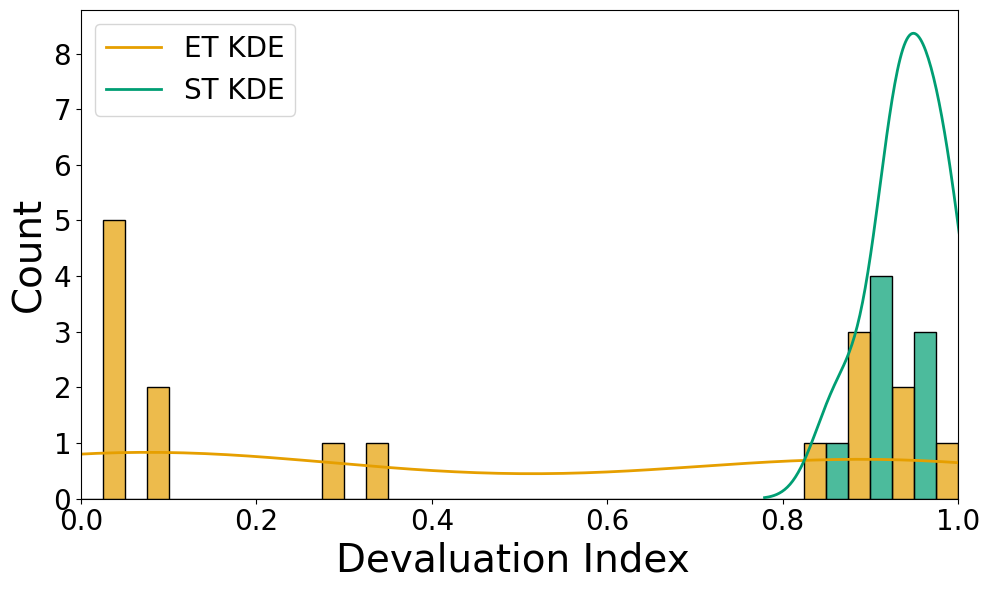

In [36]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = dev_lastANDtest

# Define the palette
palette = {"ET": "#E69F00", "ST": "#009E73"}

# Set figure size
plt.figure(figsize=(10, 6))

# Define bins (same for both groups)
num_bins = 20  # Adjust as needed
bin_min = df["dev"].min()
bin_max = df["dev"].max()
bins = np.linspace(bin_min, bin_max, num_bins + 1)  # Ensure equal bin widths

# Create histogram with dodged bars (bars next to each other)
sns.histplot(
    data=df,
    x="dev",
    hue="Group",
    bins=bins,
    multiple="dodge",  # Ensures bars are next to each other
    palette=palette,
    alpha=0.7,  # Transparency to make it clearer
    legend=True
)

# Overlay KDE plots
for group, color in palette.items():
    sns.kdeplot(
        data=df[df["Group"] == group],
        x="dev",
        color=color,
        linewidth=2,
        label=f"{group} KDE"
    )

# Labels and title
plt.xlabel("Devaluation Index ", fontsize=28)
plt.ylabel("Count", fontsize=28)
plt.xticks(fontsize=20)
plt.yticks(fontsize=20)
plt.xlim(0,1)

plt.legend(title="Group")
plt.legend(fontsize=20)  # Adjust the font size as needed
# Save and show
plt.tight_layout()
plt.savefig("dev_test_histogram_kde_dodged_pilot5.png", dpi=300, bbox_inches="tight")
plt.show()


In [37]:
et_per = (etDevResults[0]/et_last_devResults[0]).dropna()
et_per = et_per.reset_index()
et_per["Group"] = "ET"
st_per = (stDevResults[0]/st_last_devResults[0]).dropna()
st_per = st_per.reset_index()
st_per["Group"] = "ST"

In [38]:
ET_Right = (dev14['dev']/last_dev14['last'])
ET_Right = ET_Right.reset_index()
ET_Right["Group"] = "ET_Right"
ST_Right = (dev12['dev']/last_dev12['last'])
ST_Right = ST_Right.reset_index()
ST_Right["Group"] = "ST_Right"
split = pd.DataFrame([0])
split['subId'] = [1]
split["SubGroup"] = 'Split'


In [39]:
# dev_per_hands = pd.concat([ST_Left, ST_Right,ET_Left, ET_Right])
# dev_per_hands = dev_per_hands.drop(columns=['index']).rename(columns={0:'Percent'})

In [40]:
split = split.rename(columns={0:'dev'})
split_ET_Right = pd.concat([dev14[['dev','SubGroup']], split])
split_ST_Right = pd.concat([dev12[['dev','SubGroup']], split])

/var/folders/nq/v984r81x1fl7rkw1hk0cs6hc0000gr/T/ipykernel_45776/4240393912.py:42: FutureWarning: Passing `palette` without assigning `hue` is deprecated.
  sns.stripplot(


<Figure size 200x100 with 0 Axes>

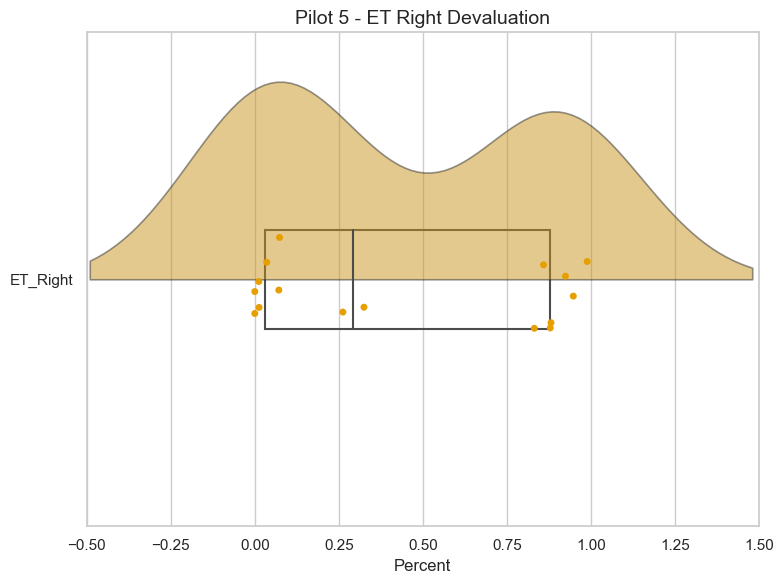

In [41]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt


df = split_ET_Right
plt.figure(figsize=(2,1))  # Set figure size before plotting

# Set style
sns.set(style="whitegrid")
# Define color palette (Make "Split" semi-transparent)
palette = {"ET_Right": "#E69F00", "Split": "#009E73"}  # Orange for main, Green for Split

# Set up the plot
fig, ax = plt.subplots(figsize=(8, 6))

# Create the violin plot, splitting by 'Group'
vplot = sns.violinplot(
    data=df, x='dev', y="SubGroup", ax=ax, hue="SubGroup",
    inner=None, linewidth=1.2, scale="width", split=True, 
    palette=palette, alpha=0.9  # Semi-transparent Split group
)
# Manually change transparency of the violin
for violin in vplot.collections:
        violin.set_alpha(0.5)  # Set transparency manually
        
        
# Overlay a boxplot
sns.boxplot(
    data=df[df["SubGroup"] == "ET_Right"],  # Filter only "ET_Left" rows
    x='dev',  # X-axis should use "Percent"
    y="SubGroup",  # Keep y as "Group" for correct positioning
    ax=ax, 
    width=0.2, 
    fliersize=0, 
    showcaps=False, 
    boxprops={"facecolor": "none"},  # Transparent boxplot
    whiskerprops={"linewidth": 0}
)

# Overlay strip plot for individual points
sns.stripplot(
    data=df, x='dev', y="SubGroup", ax=ax, jitter=True, size=5, 
    alpha=1, palette=palette
)

# Titles and labels
ax.set_title("Pilot 5 - ET Right Devaluation", fontsize=14)
ax.set_xlabel("Percent")
ax.set_ylabel("")
ax.legend_.remove()
ax.set_xlim(-0.5, 1.5)
plt.tight_layout()
plt.savefig('ET - Right Devaluation.png', dpi=300, bbox_inches='tight')  # Save as PNG (you can change the file format)
plt.show()


/var/folders/nq/v984r81x1fl7rkw1hk0cs6hc0000gr/T/ipykernel_45776/404925177.py:42: FutureWarning: Passing `palette` without assigning `hue` is deprecated.
  sns.stripplot(


<Figure size 200x100 with 0 Axes>

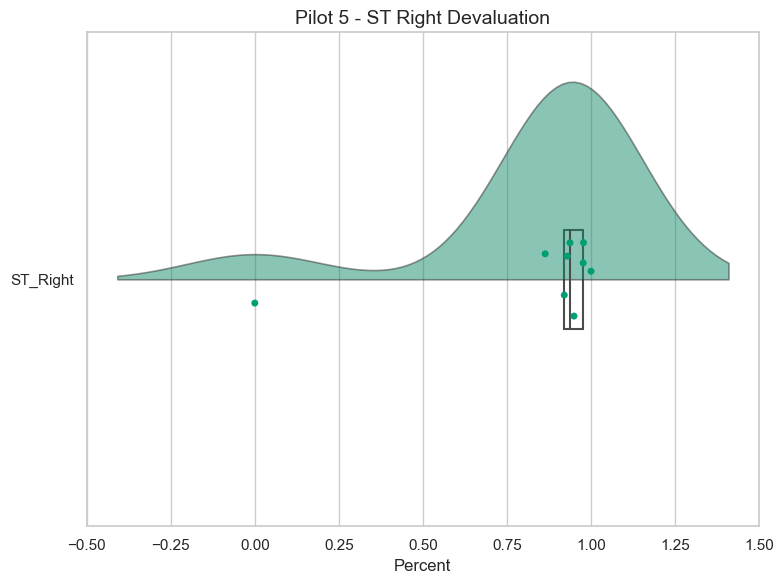

In [42]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt


df = split_ST_Right
plt.figure(figsize=(2,1))  # Set figure size before plotting

# Set style
sns.set(style="whitegrid")
# Define color palette (Make "Split" semi-transparent)
palette = {"ST_Right": "#009E73", "Split": "#E69F00"}  # Orange for main, Green for Split

# Set up the plot
fig, ax = plt.subplots(figsize=(8, 6))

# Create the violin plot, splitting by 'Group'
vplot = sns.violinplot(
    data=df, x='dev', y="SubGroup", ax=ax, hue="SubGroup",
    inner=None, linewidth=1.2, scale="width", split=True, 
    palette=palette, alpha=0.9  # Semi-transparent Split group
)
# Manually change transparency of the violin
for violin in vplot.collections:
        violin.set_alpha(0.5)  # Set transparency manually
        
        
# Overlay a boxplot
sns.boxplot(
    data=df[df["SubGroup"] == "ST_Right"],  # Filter only "ET_Left" rows
    x='dev',  # X-axis should use "Percent"
    y="SubGroup",  # Keep y as "Group" for correct positioning
    ax=ax, 
    width=0.2, 
    fliersize=0, 
    showcaps=False, 
    boxprops={"facecolor": "none"},  # Transparent boxplot
    whiskerprops={"linewidth": 0}
)

# Overlay strip plot for individual points
sns.stripplot(
    data=df, x='dev', y="SubGroup", ax=ax, jitter=True, size=5, 
    alpha=1, palette=palette
)

# Titles and labels
ax.set_title("Pilot 5 - ST Right Devaluation", fontsize=14)
ax.set_xlabel("Percent")
ax.set_ylabel("")
ax.legend_.remove()
ax.set_xlim(-0.5, 1.5)
plt.tight_layout()
plt.savefig('ST - Right Devaluation.png', dpi=300, bbox_inches='tight')  # Save as PNG (you can change the file format)
plt.show()


## Speeds & star tests:

In [43]:
st_count_Results = pd.DataFrame(results_additional[12]).rename(columns={0:'howManyStars'})
et_count_Results = pd.DataFrame(results_additional[14]).rename(columns={0:'howManyStars'})
choices12 = pd.DataFrame(results_main[12].allStars.groupby('subId').sum())
choices14 = pd.DataFrame(results_main[14].allStars.groupby('subId').sum())
st_choice_Results = pd.DataFrame(choices12)
et_choice_Results = pd.DataFrame(choices14)


In [44]:
st_count_Results['howManyStars'] = st_count_Results['howManyStars'].apply(lambda x: x[0] if isinstance(x, list) and len(x) > 0 else x)
et_count_Results['howManyStars'] = et_count_Results['howManyStars'].apply(lambda x: x[0] if isinstance(x, list) and len(x) > 0 else x)
et_count_Results['howManyStars'] = pd.to_numeric(et_count_Results['howManyStars'], errors='coerce').astype('Int64')
st_count_Results['howManyStars'] = pd.to_numeric(st_count_Results['howManyStars'], errors='coerce').astype('Int64')

In [45]:
st_accuracyCount_star = pd.DataFrame(1-(abs(st_choice_Results['allStars']-st_count_Results['howManyStars'])/st_choice_Results['allStars'])).astype('float64')
st_accuracyCount_star['Group'] = 'ST'
et_accuracyCount_star = pd.DataFrame(1-(abs(et_choice_Results['allStars']-et_count_Results['howManyStars'])/et_choice_Results['allStars'])).astype('float64')
et_accuracyCount_star['Group'] = 'ET'

In [46]:
accuracyCount_star = pd.concat([st_accuracyCount_star,et_accuracyCount_star]).rename(columns={'index':'subId'})

#### Outliers stars

Group                          
ET     6645c9cfd2c8fb647d0af388    0.428571
Name: 0, dtype: float64


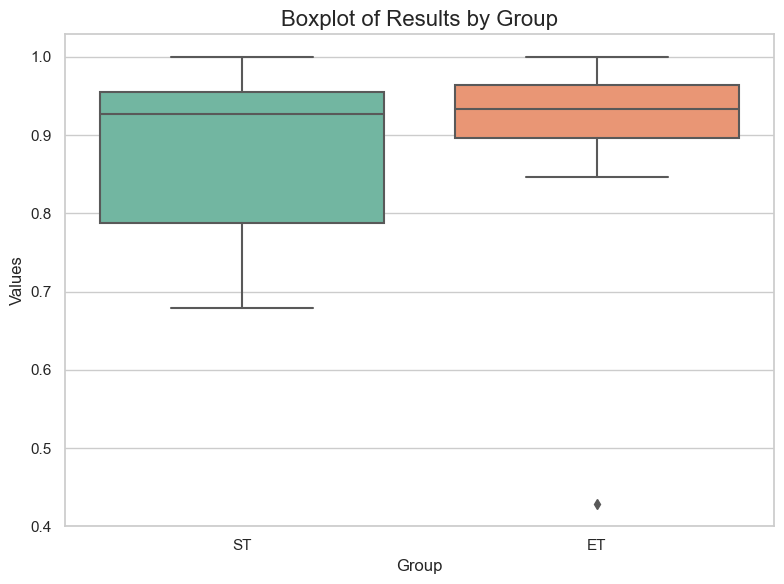

In [47]:
# Assuming your DataFrame is stored as 'df'
df = accuracyCount_star

# Grouping by 'Group' and calculating Q1, Q3, and IQR
grouped = df.groupby('Group')[0].describe()

# Calculating IQR and identifying outliers
def find_outliers(group):
    Q1 = group.quantile(0.25)
    Q3 = group.quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers = group[(group < lower_bound) | (group > upper_bound)]
    return outliers

# Apply the function to each group
outliers_stars_count = df.groupby('Group')[0].apply(find_outliers)

# Print outliers
print(outliers_stars_count)

# Optional: visualize outliers in a boxplot
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))
sns.boxplot(data=df, x="Group", y=0, palette="Set2")
plt.title('Boxplot of Results by Group', fontsize=16)
plt.xlabel('Group', fontsize=12)
plt.ylabel('Values', fontsize=12)
plt.tight_layout()
plt.show()


In [48]:
accuracyCount_star = accuracyCount_star.reset_index().rename(columns={'index':'subId'})

In [49]:
outliers_starts = pd.DataFrame(outliers_stars_count).reset_index().rename(columns={'level_1':'subId'})
outliersStars_subIds = outliers_starts['subId']

In [50]:
df_stars_cleaned = accuracyCount_star[~accuracyCount_star['subId'].isin(outliersStars_subIds)]

#### Stars stats and plot

In [51]:
df_stars_cleaned[df_stars_cleaned['Group']=='ET'].describe()

,0
count,16.000000
mean,0.939629
std,0.047639
min,0.846154
25%,0.918582
50%,0.948148
75%,0.964881
max,1.000000


In [52]:
# Test normality for each measure
print("Shapiro-Wilk test for 'ST':", shapiro(df_stars_cleaned[df_stars_cleaned['Group'] == 'ST'][0]))
print("Shapiro-Wilk test for 'ET':", shapiro(df_stars_cleaned[df_stars_cleaned['Group'] == 'ET'][0]))

Shapiro-Wilk test for 'ST': ShapiroResult(statistic=0.8038187623023987, pvalue=0.016133077442646027)
Shapiro-Wilk test for 'ET': ShapiroResult(statistic=0.9212597608566284, pvalue=0.17674081027507782)


In [53]:
from scipy.stats import mannwhitneyu, norm
import numpy as np

# Extract data for the two groups
group_ST = df_stars_cleaned[df_stars_cleaned['Group'] == 'ST'][0]
group_ET = df_stars_cleaned[df_stars_cleaned['Group'] == 'ET'][0]

# Perform Mann-Whitney U test
U_stat, p_value = mannwhitneyu(group_ST, group_ET)

# Compute effect size (r) using the Z-score method
n_ST, n_ET = len(group_ST), len(group_ET)
z_score = norm.ppf(1 - p_value / 2)  # Convert p-value to Z-score
effect_size_r = z_score / np.sqrt(n_ST + n_ET)  # r = Z / sqrt(N)

# Print results
print(f"Mann-Whitney U test: U = {U_stat:.2f}, p-value = {p_value:.6f}")
print(f"Effect size (r) = {effect_size_r:.3f}")


Mann-Whitney U test: U = 57.50, p-value = 0.243819
Effect size (r) = 0.229


In [54]:
# from scipy.stats import ttest_ind
# import numpy as np

# # Extract data for the two groups
# group_ST = df_stars_cleaned[df_stars_cleaned['Group'] == 'ST'][0]
# group_ET = df_stars_cleaned[df_stars_cleaned['Group'] == 'ET'][0]

# # Perform independent t-test
# statistic, p_value = ttest_ind(group_ST, group_ET)

# # Compute Cohen's d
# mean_ST, mean_ET = np.mean(group_ST), np.mean(group_ET)
# std_ST, std_ET = np.std(group_ST, ddof=1), np.std(group_ET, ddof=1)  # Sample std deviation
# n_ST, n_ET = len(group_ST), len(group_ET)

# # Pooled standard deviation
# s_pooled = np.sqrt(((n_ST - 1) * std_ST**2 + (n_ET - 1) * std_ET**2) / (n_ST + n_ET - 2))

# # Compute Cohen’s d
# cohens_d = (mean_ST - mean_ET) / s_pooled

# # Print results
# print(f"T-test: t = {statistic:.2f}, p-value = {p_value:.6f}")
# print(f"Cohen's d = {cohens_d:.3f}")


/var/folders/nq/v984r81x1fl7rkw1hk0cs6hc0000gr/T/ipykernel_45776/508508052.py:12: FutureWarning: Passing `palette` without assigning `hue` is deprecated.
  sns.stripplot(


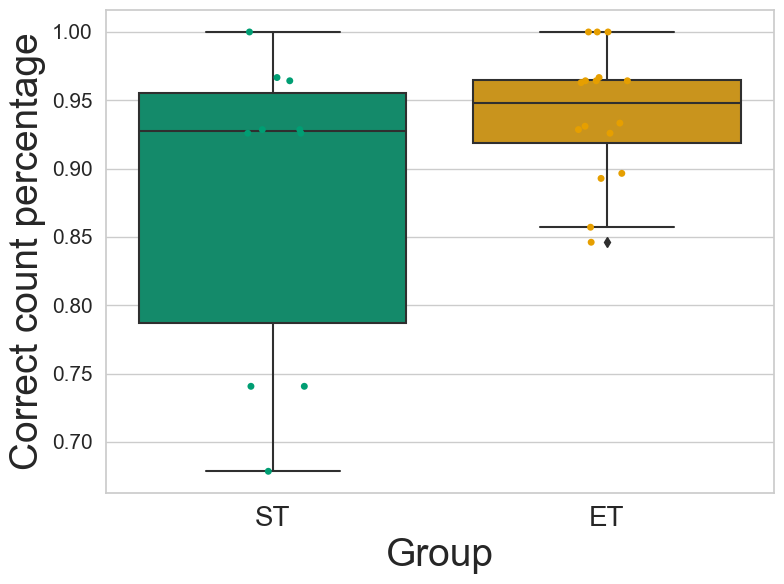

In [55]:

# Assuming your DataFrame is stored as 'df'
df = df_stars_cleaned  # Your DataFrame

# Create the plot
plt.figure(figsize=(8, 6))  # Set figure size

palette = {"ET": "#E69F00", "ST": "#009E73"}
# Create the boxplot
sns.boxplot(data=df, x="Group", y=0, palette=palette)  # Boxplot for the values

# Overlay strip plot for individual points
sns.stripplot(
    data=df, x="Group", y=0, jitter=True, size=5, alpha=1, palette=palette
)  # Stripplot on top of the boxplot

# Title and labels
# plt.title('Automaticity test - Pilot 5', fontsize=16)
plt.xlabel('Group', fontsize=28)
plt.ylabel('Correct count percentage', fontsize=28)
plt.xticks(fontsize=20)
plt.yticks(fontsize=15)
# plt.figure(figsize=(10, 6))

# Show the plot
plt.tight_layout()
plt.savefig('Automaticity test.png', dpi=300, bbox_inches='tight')  # Save as PNG (you can change the file format)

plt.show()


#### Stars and Speeds presses

In [56]:
accuracy_press12 = pd.DataFrame([(results_main[12].correctFirstBluePressStar.groupby('subId').sum()+results_main[12].correctFirstRedPressStar.groupby('subId').sum())/(results_main[12].blueChoiceStar.groupby('subId').sum()+\
results_main[12].redChoiceStar.groupby('subId').sum()), (results_main[12].correctFirstBluePressSpeeds.groupby('subId').sum()+results_main[12].correctFirstRedPressSpeeds.groupby('subId').sum())/(results_main[12].blueChoiceSpeeds.groupby('subId').sum()+\
results_main[12].redChoiceSpeeds.groupby('subId').sum())]).T.rename(columns={0: 'Stars', 1: 'Speeds'})
accuracy_press14 = pd.DataFrame([(results_main[14].correctFirstBluePressStar.groupby('subId').sum()+results_main[14].correctFirstRedPressStar.groupby('subId').sum())/(results_main[14].blueChoiceStar.groupby('subId').sum()+\
results_main[14].redChoiceStar.groupby('subId').sum()), (results_main[14].correctFirstBluePressSpeeds.groupby('subId').sum()+results_main[14].correctFirstRedPressSpeeds.groupby('subId').sum())/(results_main[14].blueChoiceSpeeds.groupby('subId').sum()+\
results_main[14].redChoiceSpeeds.groupby('subId').sum())]).T.rename(columns={0: 'Stars', 1: 'Speeds'})
st_accuracyPress_Results = pd.DataFrame(accuracy_press12)
st_accuracyPress_Results['Group'] = 'ST'
et_accuracyPress_Results = pd.DataFrame(accuracy_press14)
et_accuracyPress_Results['Group'] = 'ET'

In [57]:
accuracyPress_Results = pd.concat([st_accuracyPress_Results, et_accuracyPress_Results])


In [58]:
accuracyPress_Results.describe()

,Stars,Speeds
count,27.000000,27.000000
mean,0.874014,0.727187
std,0.212148,0.279774
min,0.000000,0.000000
25%,0.896825,0.583564
50%,0.951220,0.792208
75%,0.963415,0.935065
max,1.000000,1.000000


In [59]:
accuracyPress_Results[accuracyPress_Results['Group']=='ST'].describe()

,Stars,Speeds
count,10.000000,10.000000
mean,0.928453,0.846753
std,0.058897,0.113384
min,0.795181,0.670886
25%,0.901786,0.754808
50%,0.951220,0.850051
75%,0.952091,0.945792
max,0.988095,1.000000


In [60]:
accuracyPress_Results_stars = accuracyPress_Results[['Stars','Group']].reset_index()
accuracyPress_Results_stars = accuracyPress_Results_stars[~accuracyPress_Results_stars['subId'].isin(outliersStars_subIds)].set_index('subId')
accuracyPress_Results_Speeds = accuracyPress_Results[['Speeds','Group']]

#### Speeds presses

In [61]:
accuracyPress_Results_Speeds[accuracyPress_Results_Speeds['Group']=='ET'].describe()

,Speeds
count,17.000000
mean,0.656855
std,0.325226
min,0.000000
25%,0.450000
50%,0.772152
75%,0.911392
max,0.987342


In [62]:
# Assuming your DataFrame is stored as 'df'
df = accuracyPress_Results_Speeds

# Grouping by 'Group' and calculating Q1, Q3, and IQR
grouped = df.groupby('Group')['Speeds'].describe()

# Calculating IQR and identifying outliers
def find_outliers(group):
    Q1 = group.quantile(0.25)
    Q3 = group.quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers = group[(group < lower_bound) | (group > upper_bound)]
    return outliers

# Apply the function to each group
outliers_speeds = df.groupby('Group')['Speeds'].apply(find_outliers)

# Print outliers
print(outliers_speeds)


# plt.figure(figsize=(8, 6))
# sns.boxplot(data=df, x="Group", y='Stars', palette="Set2")
# plt.title('Boxplot of Results by Group', fontsize=16)
# plt.xlabel('Group', fontsize=12)
# plt.ylabel('Values', fontsize=12)
# plt.tight_layout()
# plt.show()


Series([], Name: Speeds, dtype: float64)


In [63]:
outliers_Speeds_press = pd.DataFrame(outliers_speeds).reset_index()
outliersSpeedsPress_subIds = outliers_Speeds_press['subId']
accuracyPress_Results_Speeds = accuracyPress_Results_Speeds.reset_index()

In [64]:
df_SpeedsPress_cleaned = accuracyPress_Results_Speeds[~accuracyPress_Results_Speeds['subId'].isin(outliersSpeedsPress_subIds)]

In [65]:
# Test normality for each measure
print("Shapiro-Wilk test for 'ST':", shapiro(df_SpeedsPress_cleaned[df_SpeedsPress_cleaned['Group'] == 'ST']['Speeds']))
print("Shapiro-Wilk test for 'ET':", shapiro(df_SpeedsPress_cleaned[df_SpeedsPress_cleaned['Group'] == 'ET']['Speeds']))

Shapiro-Wilk test for 'ST': ShapiroResult(statistic=0.8996648192405701, pvalue=0.2172469198703766)
Shapiro-Wilk test for 'ET': ShapiroResult(statistic=0.8628708124160767, pvalue=0.01695682667195797)


In [66]:
# statistic, p_value = ttest_ind(df_SpeedsPress_cleaned[df_SpeedsPress_cleaned['Group']=='ST']['Speeds'], df_SpeedsPress_cleaned[df_SpeedsPress_cleaned['Group']=='ET']['Speeds'])
# print(statistic, p_value)

In [67]:
from scipy.stats import mannwhitneyu, norm
import numpy as np

# Extract data for the two groups
group_ST = df_SpeedsPress_cleaned[df_SpeedsPress_cleaned['Group'] == 'ST']['Speeds']
group_ET = df_SpeedsPress_cleaned[df_SpeedsPress_cleaned['Group'] == 'ET']['Speeds']

# Perform Mann-Whitney U test
U_stat, p_value = mannwhitneyu(group_ST, group_ET, alternative='two-sided')

# Compute effect size (r) using the Z-score method
n_ST, n_ET = len(group_ST), len(group_ET)
z_score = norm.ppf(1 - p_value / 2)  # Convert p-value to Z-score
effect_size_r = z_score / np.sqrt(n_ST + n_ET)  # r = Z / sqrt(N)

# Print results
print(f"Mann-Whitney U test: U = {U_stat:.2f}, p-value = {p_value:.6f}")
print(f"Effect size (r) = {effect_size_r:.3f}")


Mann-Whitney U test: U = 110.50, p-value = 0.209113
Effect size (r) = 0.242


/var/folders/nq/v984r81x1fl7rkw1hk0cs6hc0000gr/T/ipykernel_45776/23894490.py:12: FutureWarning: Passing `palette` without assigning `hue` is deprecated.
  sns.stripplot(


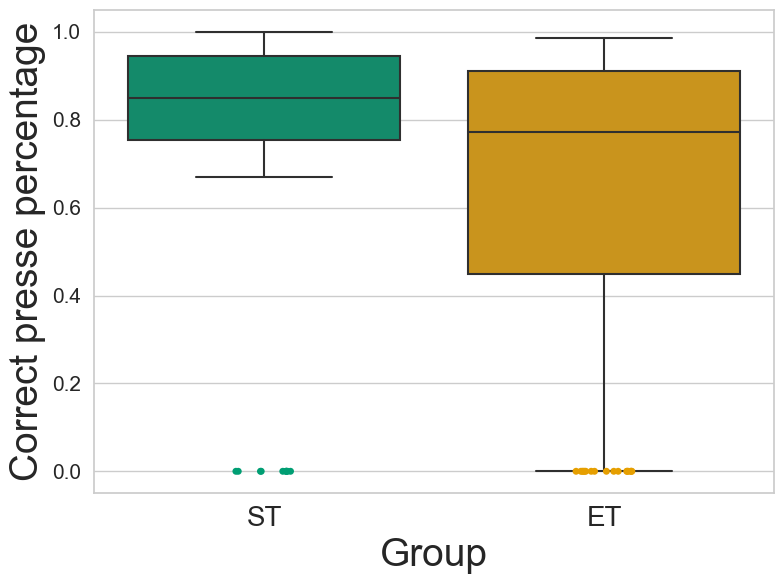

In [68]:

# Assuming your DataFrame is stored as 'df'
df = df_SpeedsPress_cleaned  # Your DataFrame

# Create the plot
plt.figure(figsize=(8, 6))  # Set figure size

palette = {"ET": "#E69F00", "ST": "#009E73"}
# Create the boxplot
sns.boxplot(data=df, x="Group", y='Speeds', palette=palette)  # Boxplot for the values

# Overlay strip plot for individual points
sns.stripplot(
    data=df, x="Group", y=0, jitter=True, size=5, alpha=1, palette=palette
)  # Stripplot on top of the boxplot

# Title and labels
# plt.title('Automaticity test - Pilot 5', fontsize=16)
plt.xlabel('Group', fontsize=28)
plt.ylabel('Correct presse percentage', fontsize=28)
plt.xticks(fontsize=20)
plt.yticks(fontsize=15)

# Show the plot
plt.tight_layout()
plt.savefig('Infelxibilty test.png', dpi=300, bbox_inches='tight')  # Save as PNG (you can change the file format)

plt.show()


#### Stars presses

In [69]:
# Assuming your DataFrame is stored as 'df'
df = accuracyPress_Results_stars

# Grouping by 'Group' and calculating Q1, Q3, and IQR
grouped = df.groupby('Group')['Stars'].describe()

# Calculating IQR and identifying outliers
def find_outliers(group):
    Q1 = group.quantile(0.25)
    Q3 = group.quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers = group[(group < lower_bound) | (group > upper_bound)]
    return outliers

# Apply the function to each group
outliers_stars = df.groupby('Group')['Stars'].apply(find_outliers)

# Print outliers
print(outliers_stars)


# plt.figure(figsize=(8, 6))
# sns.boxplot(data=df, x="Group", y='Stars', palette="Set2")
# plt.title('Boxplot of Results by Group', fontsize=16)
# plt.xlabel('Group', fontsize=12)
# plt.ylabel('Values', fontsize=12)
# plt.tight_layout()
# plt.show()


Group  subId                   
ET     6645c9cfd2c8fb647d0af38f    0.000000
       6645c9cfd2c8fb647d0af39e    0.743902
       6649b980d2c8fb647d0af409    0.380952
ST     6645cb96d2c8fb647d0af3a4    0.795181
Name: Stars, dtype: float64


In [70]:
outliers_stars = pd.DataFrame(outliers_stars).reset_index()

In [71]:
outliers_Stars_press = pd.DataFrame(outliers_stars).reset_index()
outliersStarsPress_subIds = outliers_stars['subId']
accuracyPress_Results_stars = accuracyPress_Results_stars.reset_index()

In [72]:
df_StarsPress_cleaned = accuracyPress_Results_stars[~accuracyPress_Results_stars['subId'].isin(outliersStarsPress_subIds)]

In [73]:
# Test normality for each measure
print("Shapiro-Wilk test for 'ST':", shapiro(df_StarsPress_cleaned[df_StarsPress_cleaned['Group']=='ST']['Stars']))
print("Shapiro-Wilk test for 'ET':", shapiro(df_StarsPress_cleaned[df_StarsPress_cleaned['Group']=='ET']['Stars']))

Shapiro-Wilk test for 'ST': ShapiroResult(statistic=0.857175350189209, pvalue=0.08932322263717651)
Shapiro-Wilk test for 'ET': ShapiroResult(statistic=0.9316476583480835, pvalue=0.3580944538116455)


In [74]:
from scipy.stats import ttest_ind
import numpy as np

# Extract data for the two groups
group_ST = df_StarsPress_cleaned[df_StarsPress_cleaned['Group']=='ST']['Stars']
group_ET = df_StarsPress_cleaned[df_StarsPress_cleaned['Group']=='ET']['Stars']

# Perform independent t-test
statistic, p_value = ttest_ind(group_ST, group_ET)

# Compute Cohen's d
mean_ST, mean_ET = np.mean(group_ST), np.mean(group_ET)
std_ST, std_ET = np.std(group_ST, ddof=1), np.std(group_ET, ddof=1)  # Sample std deviation
n_ST, n_ET = len(group_ST), len(group_ET)

# Pooled standard deviation
s_pooled = np.sqrt(((n_ST - 1) * std_ST**2 + (n_ET - 1) * std_ET**2) / (n_ST + n_ET - 2))

# Compute Cohen’s d
cohens_d = (mean_ST - mean_ET) / s_pooled

# Print results
print(f"T-test: t = {statistic:.2f}, p-value = {p_value:.6f}")
print(f"Cohen's d = {cohens_d:.3f}")


T-test: t = 0.16, p-value = 0.870997
Cohen's d = 0.071


In [75]:
df_StarsPress_cleaned.describe()#[df_StarsPress_cleaned['Group']=='ET'].describe()

,Stars
count,22.000000
mean,0.941588
std,0.038772
min,0.841463
25%,0.917457
50%,0.951220
75%,0.964068
max,1.000000


In [76]:
df_stars_cleaned = df_stars_cleaned.rename(columns={0:'Count'}).set_index('subId').drop(columns=['Group'])
accuracyPress_Results_stars = accuracyPress_Results_stars.rename(columns={'Stars':'Presses'}).set_index('subId')
stars5 = pd.concat([df_stars_cleaned, accuracyPress_Results_stars], axis=1).dropna()
stars5['Pilot'] = 5

In [77]:
stars5.to_csv('stars5.csv')

## RT

In [78]:
def compute_effect_size(U, n1, n2):
    """Compute effect size r using the Z-score method."""
    mean_U = (n1 * n2) / 2  # Expected U
    std_U = np.sqrt((n1 * n2 * (n1 + n2 + 1)) / 12)  # Standard deviation of U
    Z = (U - mean_U) / std_U  # Compute Z-score
    r = abs(Z) / np.sqrt(n1 + n2)  # Effect size r
    return r, Z

### RT for stars test:

In [79]:
RTs = {}

for i in range(12, 15):
    if i==13:
        continue
    RT = {}
    RT['Blue'] = {}
    RT['Red'] = {}

    # Filter relevant data
    dfs[i] = dfs[i][dfs[i].subId.isin(relevent_subIds[i])]
    dfs[i] = dfs[i][~dfs[i]['subId'].isin(outliers_stars)]

    # Iterate over rows for BLUE choices
    for row in dfs[i][['subId', 'correctFirstBluePressStar', 'blueChoiceStar']].dropna().iterrows():
        RT_blue_row = {}
        subId = row[1].subId  # Extract subId

        for ind, correctFirstBluePressStar in enumerate(row[1].correctFirstBluePressStar):
            valid_choices = [x for x in row[1].blueChoiceStar if x < correctFirstBluePressStar]
            RT_blue_row[ind] = correctFirstBluePressStar - valid_choices[-1] if valid_choices else None  # Handle empty list

        if len(RT_blue_row) > 0:
            RT['Blue'][row[0]] = {'RTs': list(RT_blue_row.values()), 'subId': subId}  # Store subId

    # Iterate over rows for RED choices
    for row in dfs[i][['subId', 'correctFirstRedPressStar', 'redChoiceStar']].dropna().iterrows():
        RT_red_row = {}
        subId = row[1].subId  # Extract subId

        for ind, correctFirstRedPressStar in enumerate(row[1].correctFirstRedPressStar):
            valid_choices = [x for x in row[1].redChoiceStar if x < correctFirstRedPressStar]
            RT_red_row[ind] = correctFirstRedPressStar - valid_choices[-1] if valid_choices else None  # Handle empty list

        if len(RT_red_row) > 0:
            RT['Red'][row[0]] = {'RTs': list(RT_red_row.values()), 'subId': subId}  # Store subId

    # Convert to DataFrame
    RTs[i] = pd.DataFrame.from_dict({(key, subkey): values 
                                     for key, subdict in RT.items() 
                                     for subkey, values in subdict.items()}, 
                                     orient='index')

    # Reset index to make 'Color' and 'RowIndex' columns
    RTs[i].reset_index(inplace=True)
    RTs[i].rename(columns={'level_0': 'Color', 'level_1': 'RowIndex'}, inplace=True)

    # Ensure 'subId' is set as an index or a column
    RTs[i] = RTs[i].set_index('subId')

    # Expand dictionary values into separate columns
    RTs[i] = pd.concat([RTs[i], RTs[i].apply(lambda row: pd.Series(row[0]), axis=1)], axis=1)

    # Drop unnecessary nested dictionary column
    RTs[i].drop(columns=[0], inplace=True, errors='ignore')



In [80]:
def to_list(a):
    if isinstance(a, float):
        return [a]
    return a

In [81]:
mean_RTs = {}

for grp, RT in RTs.items():
    # Compute mean RTs while keeping 'subId'
    mean_df = RT.groupby(["subId", "Color"])["RTs"].apply(lambda x: 
        pd.Series([item for sublist in x.dropna() for item in to_list(sublist)]).mean()
    ).unstack()  # Convert 'Color' categories into separate columns

    # Store the result
    mean_RTs[grp] = mean_df.reset_index()  # Ensure 'subId' is a column


In [82]:
mean_RTs[12]

Color,subId,Blue,Red
0,6645cb96d2c8fb647d0af3a1,705.000000,672.517241
1,6645cb96d2c8fb647d0af3a2,570.853659,572.452381
2,6645cb96d2c8fb647d0af3a4,724.826087,698.162791
3,6645cb96d2c8fb647d0af3a5,584.466667,623.771429
4,6645cb96d2c8fb647d0af3a7,557.581395,557.236842
5,6645cb96d2c8fb647d0af3a9,678.378378,697.780488
6,6645cb96d2c8fb647d0af3aa,687.909091,707.743590
7,6645cb96d2c8fb647d0af3ad,678.108696,677.812500
8,6645cb96d2c8fb647d0af3af,612.153846,646.725000
9,6645cb96d2c8fb647d0af3b0,601.739130,629.750000


In [83]:
BandRST = pd.DataFrame(mean_RTs[12]).reset_index()
BandRST["Group"]="ST"
BandRET = pd.DataFrame(mean_RTs[14]).reset_index()
BandRET["Group"]="ET"
BandR = pd.concat([BandRST,BandRET])
BandR = BandR.drop(columns = "index")
BandR['Hand_mean'] = BandR[['Blue', 'Red']].mean(axis=1)

In [84]:
BandR = BandR.reset_index().melt(id_vars=['subId', 'Group'], 
                                  value_vars=['Hand_mean'], 
                                  var_name='Color', 
                                  value_name='MeanRT')


In [85]:
# Assuming your DataFrame is stored as 'df'
df = BandR

# Grouping by 'Group' and calculating Q1, Q3, and IQR
grouped = df.groupby('Group')['MeanRT'].describe()

# Apply the function to each group
outliers_RT_stars = df.groupby('Group')['MeanRT'].apply(find_outliers)

# Print outliers
print(outliers_RT_stars)

Group    
ET     11    416.495726
       17    405.575113
Name: MeanRT, dtype: float64


In [86]:
outliers_RT_Stars = pd.DataFrame(outliers_RT_stars).reset_index()
outliers_RT_Stars_subIds = outliers_RT_Stars['level_1']
BandR = BandR.reset_index()

In [87]:
df_RT_Stars_cleaned = BandR[~BandR['index'].isin(outliers_RT_Stars_subIds)]

In [88]:
statistic, p_value = ttest_ind(df_RT_Stars_cleaned[df_RT_Stars_cleaned['Group']=='ST']['MeanRT'].dropna(), df_RT_Stars_cleaned[df_RT_Stars_cleaned['Group']=='ET']['MeanRT'].dropna())
print(statistic, p_value)

1.4060821255390779 0.17366730919182885


In [89]:
df_RT_Stars_cleaned[df_RT_Stars_cleaned['Group']=='ET']['MeanRT'].describe()

count     14.000000
mean     613.546677
std       50.611874
min      492.102381
25%      581.960607
50%      623.847435
75%      646.697268
max      682.521552
Name: MeanRT, dtype: float64

In [90]:
# Test normality for each measure
print("Shapiro-Wilk test for 'ST':", shapiro(df_RT_Stars_cleaned[df_RT_Stars_cleaned['Group']=='ST']['MeanRT'].dropna()))
print("Shapiro-Wilk test for 'ET':", shapiro(df_RT_Stars_cleaned[df_RT_Stars_cleaned['Group']=='ET']['MeanRT'].dropna()))

Shapiro-Wilk test for 'ST': ShapiroResult(statistic=0.905232310295105, pvalue=0.2498198002576828)
Shapiro-Wilk test for 'ET': ShapiroResult(statistic=0.9376621246337891, pvalue=0.38918787240982056)


In [91]:
# statistic, p_value = ttest_ind(BandRST[0].dropna(), BandRET[0].dropna())
# print(statistic, p_value)

In [177]:
# Extract data for the two groups
group_ST = df_RT_Stars_cleaned[df_RT_Stars_cleaned['Group']=='ST']['MeanRT'].dropna()
group_ET = df_RT_Stars_cleaned[df_RT_Stars_cleaned['Group']=='ET']['MeanRT'].dropna()
# Perform independent t-test
statistic, p_value = ttest_ind(group_ST, group_ET)

# Compute Cohen's d
mean_ST, mean_ET = np.mean(group_ST), np.mean(group_ET)
std_ST, std_ET = np.std(group_ST, ddof=1), np.std(group_ET, ddof=1)  # Sample std deviation
n_ST, n_ET = len(group_ST), len(group_ET)

# Pooled standard deviation
s_pooled = np.sqrt(((n_ST - 1) * std_ST**2 + (n_ET - 1) * std_ET**2) / (n_ST + n_ET - 2))

# Compute Cohen’s d
cohens_d = (mean_ST - mean_ET) / s_pooled

# Welch-Satterthwaite degrees of freedom
df = (std_ST**2/n_ST + std_ET**2/n_ET)**2 / (
    (std_ST**2/n_ST)**2/(n_ST-1) + (std_ET**2/n_ET)**2/(n_ET-1)
)

# Print results
print(f"T-test: t{df:.2f} = {statistic:.2f}, p-value = {p_value:.6f}")
print(f"Cohen's d = {cohens_d:.3f}")


T-test: t18.34 = 1.41, p-value = 0.173667
Cohen's d = 0.582


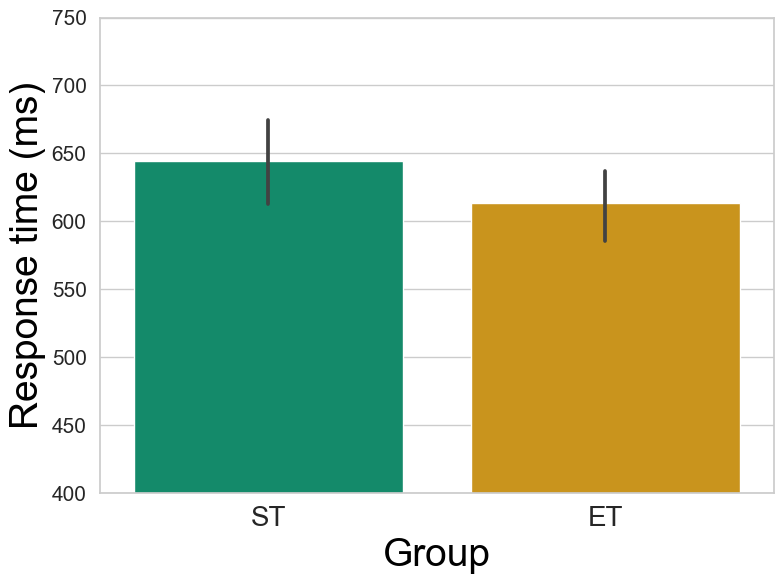

In [93]:

# Define custom colors
custom_palette = {"ET": "#E69F00", "ST": "#009E73"}
plt.figure(figsize=(8, 6))  # Set figure size

# Create the bar plot with custom colors
ax = sns.barplot(data=df_RT_Stars_cleaned, x="Group", y="MeanRT", palette=custom_palette)

# Set axis limits
plt.ylim(400, 750)

# Customize axis labels
ax.set_xlabel("Group", fontdict={'fontsize': 12, 'color': 'black'})
ax.set_ylabel("Time (ms)", fontdict={'fontsize': 12, 'color': 'black'})

# plt.title('Stars response time - Pilot 5', fontsize=16)
plt.xlabel('Group', fontsize=28)
plt.ylabel('Response time (ms)', fontsize=28)
plt.xticks(fontsize=20)
plt.yticks(fontsize=15)
# Save the figure
plt.tight_layout()
plt.savefig("response_time_stars.png")

# Show the plot
plt.show()


In [228]:
df_RT_Stars_cleaned['Pilot'] = 5
df_RT_Stars_cleaned.to_csv('df_RT_Stars_cleaned5.csv')

In [232]:
df_RT_Stars_cleaned.query('Group == "ET"').describe()

,index,MeanRT,Pilot
count,14.000000,14.000000,14.0
mean,18.000000,613.546677,5.0
std,4.755564,50.611874,0.0
min,10.000000,492.102381,5.0
25%,14.250000,581.960607,5.0
50%,18.500000,623.847435,5.0
75%,21.750000,646.697268,5.0
max,25.000000,682.521552,5.0


In [229]:
df_RT_Stars_cleaned.head()

,index,subId,Group,Color,MeanRT,Pilot,step
0,0,6645cb96d2c8fb647d0af3a1,ST,Hand_mean,688.758621,5,Stars
1,1,6645cb96d2c8fb647d0af3a2,ST,Hand_mean,571.653020,5,Stars
2,2,6645cb96d2c8fb647d0af3a4,ST,Hand_mean,711.494439,5,Stars
3,3,6645cb96d2c8fb647d0af3a5,ST,Hand_mean,604.119048,5,Stars
4,4,6645cb96d2c8fb647d0af3a7,ST,Hand_mean,557.409119,5,Stars


### RT training

In [95]:
# Create a function to filter elements in the list that are greater than 180,000 milliseconds
def filter_list_RTs(lst):
    if len([item for item in lst if isinstance(item, int) and item > 180000])==0:
           return np.nan
    return [item for item in lst if isinstance(item, int) and item > 180000]

In [96]:
dfs_for_RT_blue = {}
dfs_for_RT_red = {}
dfs_for_RT = {}

dfs_for_RT_blue[14] = dfs[14][dfs[14].subId.isin(relevent_subIds[14])]\
.set_index(['subId',dfs[14][dfs[14].subId.isin(relevent_subIds[14])].createdAt.str[:10]])[['correctFirstBluePress', 'blueChoice']].dropna().reset_index()
dfs_for_RT_blue[14] = dfs_for_RT_blue[14][dfs_for_RT_blue[14]['correctFirstBluePress'].apply(lambda x: isinstance(x, list) and len(x) > 0)]
dfs_for_RT_blue[14]['correctFirstBluePress'] = dfs_for_RT_blue[14]['correctFirstBluePress'].apply(filter_list_RTs)
dfs_for_RT_blue[14]['blueChoice'] = dfs_for_RT_blue[14]['blueChoice'].apply(filter_list_RTs)
dfs_for_RT_blue[14].sort_values(by='createdAt', ascending=True, inplace=True)
dfs_for_RT_blue[14] = dfs_for_RT_blue[14].groupby('subId').apply(fix_subId)
dfs_for_RT_blue[14] = dfs_for_RT_blue[14].drop(columns=['subId'])

dfs_for_RT_red[14] = dfs[14][dfs[14].subId.isin(relevent_subIds[14])]\
.set_index(['subId',dfs[14][dfs[14].subId.isin(relevent_subIds[14])].createdAt.str[:10]])[['correctFirstRedPress', 'redChoice']].dropna().reset_index()
dfs_for_RT_red[14] = dfs_for_RT_red[14][dfs_for_RT_red[14]['correctFirstRedPress'].apply(lambda x: isinstance(x, list) and len(x) > 0)]
dfs_for_RT_red[14]['correctFirstRedPress'] = dfs_for_RT_red[14]['correctFirstRedPress'].apply(filter_list_RTs)
dfs_for_RT_red[14]['redChoice'] = dfs_for_RT_red[14]['redChoice'].apply(filter_list_RTs)
dfs_for_RT_red[14].sort_values(by='createdAt', ascending=True, inplace=True)
dfs_for_RT_red[14] = dfs_for_RT_red[14].groupby('subId').apply(fix_subId)
dfs_for_RT_red[14] = dfs_for_RT_red[14].drop(columns=['subId','createdAt'])

    
for i in range (11, 13):    
    dfs_for_RT_blue[12] = dfs[12][dfs[12].subId.isin(relevent_subIds[12])]\
    .set_index(['subId',dfs[12][dfs[12].subId.isin(relevent_subIds[12])].createdAt.str[:10]])[['correctFirstBluePress', 'blueChoice']].dropna().reset_index()
    dfs_for_RT_blue[12] = dfs_for_RT_blue[12][dfs_for_RT_blue[12]['correctFirstBluePress'].apply(lambda x: isinstance(x, list) and len(x) > 0)]
    dfs_for_RT_blue[12]['correctFirstBluePress'] = dfs_for_RT_blue[12]['correctFirstBluePress'].apply(filter_list_RTs)
    dfs_for_RT_blue[12]['blueChoice'] = dfs_for_RT_blue[12]['blueChoice'].apply(filter_list_RTs)
    dfs_for_RT_blue[12].sort_values(by=['subId', 'createdAt'])
    dfs_for_RT_blue[12] = dfs_for_RT_blue[12].groupby('subId', as_index=True).first()
    
    dfs_for_RT_red[12] = dfs[12][dfs[12].subId.isin(relevent_subIds[12])]\
    .set_index(['subId',dfs[12][dfs[12].subId.isin(relevent_subIds[12])].createdAt.str[:10]])[['correctFirstRedPress', 'redChoice']].dropna().reset_index()
    dfs_for_RT_red[12] = dfs_for_RT_red[12][dfs_for_RT_red[12]['correctFirstRedPress'].apply(lambda x: isinstance(x, list) and len(x) > 0)]
    dfs_for_RT_red[12]['correctFirstRedPress'] = dfs_for_RT_red[12]['correctFirstRedPress'].apply(filter_list_RTs)
    dfs_for_RT_red[12]['redChoice'] = dfs_for_RT_red[12]['redChoice'].apply(filter_list_RTs)
    dfs_for_RT_red[12] = dfs_for_RT_red[12].groupby('subId', as_index=True).first()
    dfs_for_RT_red[12] = dfs_for_RT_red[12].drop(columns=['createdAt'])

for i in range (12, 15):
    if i == 13:
        continue
    dfs_for_RT[i] = pd.concat([dfs_for_RT_blue[i], dfs_for_RT_red[i]], axis=1).reset_index().rename(columns={'index': 'subId'})

In [97]:
# Remove the first element from each list in the 'correctFirstBluePress' column for all rows
for i in range(12, 15):
    if i==13:
        continue
    dfs_for_RT[i]['correctFirstBluePress'] = dfs_for_RT[i]['correctFirstBluePress'].apply(
        lambda x: x[1:] if isinstance(x, list) and len(x) > 0 else x
    )
    dfs_for_RT[i]['correctFirstRedPress'] = dfs_for_RT[i]['correctFirstRedPress'].apply(
        lambda x: x[1:] if isinstance(x, list) and len(x) > 0 else x
    )


In [98]:
RTs_general = {}
Ts_general = {}
for i in range(12, 15):
    if i==13:
        continue
    RT = {}
    RT['Blue'] = {}
    RT['Red'] = {}
    RT_df = dfs_for_RT[i]
    for row in RT_df[['subId', 'createdAt', 'correctFirstBluePress', 'blueChoice']].dropna().iterrows():
        RT_blue_row = {}
        subId = row[1].subId
        createdAt = row[1].createdAt
        
        for ind, correctFirstBluePress in enumerate(sorted(row[1].correctFirstBluePress)):
            row[1].blueChoice = sorted(row[1].blueChoice) 
            RT_blue_row[ind] = correctFirstBluePress - [x for x in row[1].blueChoice if x < correctFirstBluePress][-1]
        
        if len(RT_blue_row) > 0:
            RT['Blue'][row[0]] = {'RTs': list(RT_blue_row.values()), 'subId': subId, 'createdAt': createdAt}

    for row in RT_df[['subId', 'createdAt', 'correctFirstRedPress', 'redChoice']].dropna().iterrows():
        RT_red_row = {}
        subId = row[1].subId
        createdAt = row[1].createdAt

        for ind, correctFirstRedPress in enumerate(sorted(row[1].correctFirstRedPress)):
            RT_red_row[ind] = correctFirstRedPress - [x for x in row[1].redChoice if x < correctFirstRedPress][-1]
        
        if len(RT_red_row) > 0:
            RT['Red'][row[0]] = {'RTs': list(RT_red_row.values()), 'subId': subId, 'createdAt': createdAt}

        # Convert nested dictionary to DataFrame
        RTs_general[i] = pd.DataFrame.from_dict({(key, subkey): values 
                                                 for key, subdict in RT.items() 
                                                 for subkey, values in subdict.items()}, 
                                                 orient='index')

        # Reset index so 'Color' and 'RowIndex' become columns
        RTs_general[i].reset_index(inplace=True)
        RTs_general[i].rename(columns={'level_0': 'Color', 'level_1': 'RowIndex'}, inplace=True)
        RTs_general[i] = RTs_general[i].set_index('subId')
        # Expand dictionary values (RTs, subId, createdAt) into separate columns
        RTs_general[i] = pd.concat([RTs_general[i], RTs_general[i].apply(lambda row: pd.Series(row[0]), axis=1)], axis=1)

        # Drop the original column that stored the dictionaries (it has been expanded)
        RTs_general[i].drop(columns=[0], inplace=True, errors='ignore')  # 'ignore' avoids errors if the column doesn't exist

In [99]:
df_reset = {}
df_means = {}

for i in range (12,15):
    if i==13:
        continue
    # Reset index to ensure 'subId' and 'Color' are columns
    df_reset[i] = RTs_general[i].reset_index().dropna()

    # Compute the mean RTs for each combination of 'subId' and 'Color'
    df_means[i] = df_reset[i].groupby(['subId', 'Color'])['RTs'].apply(lambda x: np.mean(x.values[0]) if isinstance(x.values[0], list) else np.nan).unstack()

    # Rename columns for clarity
    df_means[i].columns = ['MeanRT_Blue', 'MeanRT_Red']
    # df_means[i]['Mean_All'] = df_means[i][['MeanRT_Blue', 'MeanRT_Red']].mean(axis=1)
    if i in range (11,13):
        df_means[i]['Group'] = 'ST'
    else:
        df_means[i]['Group'] = 'ET'

In [100]:
df_means = pd.concat([df_means[12],df_means[14]])

In [101]:
# Reset index to make 'subId' a column before melting
RT_means_training = df_means.reset_index().melt(id_vars=['subId', 'Group'], 
                                  value_vars=['MeanRT_Blue', 'MeanRT_Red'], 
                                  var_name='Color', 
                                  value_name='MeanRT')


In [102]:
# Assuming your DataFrame is stored as 'df'
df = RT_means_training

# Grouping by 'Group' and calculating Q1, Q3, and IQR
grouped = df.groupby('Group')['MeanRT'].describe()

# Calculating IQR and identifying outliers
def find_outliers(group):
    Q1 = group.quantile(0.25)
    Q3 = group.quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers = group[(group < lower_bound) | (group > upper_bound)]
    return outliers

# Apply the function to each group
outliers_RT_training = df.groupby('Group')['MeanRT'].apply(find_outliers)

# Print outliers
print(outliers_RT_training)

Group    
ET     10    410.291667
       21    677.862069
       33    383.518519
       44    683.272727
       45    678.280000
ST     4     281.717949
       27    328.166667
Name: MeanRT, dtype: float64


In [103]:
outliers_RT_training

Group    
ET     10    410.291667
       21    677.862069
       33    383.518519
       44    683.272727
       45    678.280000
ST     4     281.717949
       27    328.166667
Name: MeanRT, dtype: float64

In [104]:
outliers_RT_training = pd.DataFrame(outliers_RT_training).reset_index()
outliers_RT_training_subIds = outliers_RT_training['level_1']
RT_means_training = RT_means_training.reset_index()

In [105]:
df_RT_training_cleaned = RT_means_training[~RT_means_training['index'].isin(outliers_RT_training_subIds)]

In [106]:
# Test normality for each measure
print("Shapiro-Wilk test for 'ST':", shapiro(RT_means_training[RT_means_training['Group']=='ST']['MeanRT'].dropna()))
print("Shapiro-Wilk test for 'ET':", shapiro(RT_means_training[RT_means_training['Group']=='ET']['MeanRT'].dropna()))

Shapiro-Wilk test for 'ST': ShapiroResult(statistic=0.6497416496276855, pvalue=1.0098489838128444e-05)
Shapiro-Wilk test for 'ET': ShapiroResult(statistic=0.87331223487854, pvalue=0.0041716089472174644)


In [107]:
df_RT_Stars_cleaned

,index,subId,Group,Color,MeanRT,Pilot
0,0,6645cb96d2c8fb647d0af3a1,ST,Hand_mean,688.758621,5
1,1,6645cb96d2c8fb647d0af3a2,ST,Hand_mean,571.653020,5
2,2,6645cb96d2c8fb647d0af3a4,ST,Hand_mean,711.494439,5
3,3,6645cb96d2c8fb647d0af3a5,ST,Hand_mean,604.119048,5
4,4,6645cb96d2c8fb647d0af3a7,ST,Hand_mean,557.409119,5
5,5,6645cb96d2c8fb647d0af3a9,ST,Hand_mean,688.079433,5
6,6,6645cb96d2c8fb647d0af3aa,ST,Hand_mean,697.826340,5
7,7,6645cb96d2c8fb647d0af3ad,ST,Hand_mean,677.960598,5
8,8,6645cb96d2c8fb647d0af3af,ST,Hand_mean,629.439423,5
9,9,6645cb96d2c8fb647d0af3b0,ST,Hand_mean,615.744565,5


In [108]:
RT_means_training['Pilot'] = 5
df_RT_Stars_cleaned['Pilot'] = 5
df_RT_Stars_cleaned.to_csv('df_RT_Stars_cleaned5.csv')

/var/folders/nq/v984r81x1fl7rkw1hk0cs6hc0000gr/T/ipykernel_45776/2827191922.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_RT_Stars_cleaned['Pilot'] = 5


In [109]:
df_RT_Stars_cleaned = df_RT_Stars_cleaned.rename(columns={'Response time':'MeanRT'})
df_RT_Stars_cleaned['step'] = 'Stars'
RT_means_training['step'] = 'Training'
#,RT_means_training['MeanRT']

In [110]:
rt_stars_training = pd.concat([df_RT_Stars_cleaned,RT_means_training])

In [235]:
rt_stars_training.query('Group=="ST" and step=="Training"').describe()

,index,MeanRT,Pilot
count,20.000000,20.000000,20.0
mean,16.000000,587.871558,5.0
std,12.161198,102.427144,0.0
min,0.000000,281.717949,5.0
25%,4.750000,578.278125,5.0
50%,16.000000,625.680545,5.0
75%,27.250000,639.021364,5.0
max,32.000000,665.065217,5.0


In [112]:
# rt_stars_training = rt_stars_training.drop(columns=['index','Pilot','subId','Color'])
rt_stars_training['Pilot'] = 5
rt_stars_training.to_csv('rt_stars_training5.csv')

### RT for Speeds

In [178]:
RTs_Speeds = {}

for i in range(12, 15):
    if i == 13:
        continue
    RT = {'subId':{},'Blue': {}, 'Red': {}}
    dfs[i] = dfs[i][dfs[i].subId.isin(relevent_subIds[i])]
    dfs[i] = dfs[i][~dfs[i]['subId'].isin(outliersSpeedsPress_subIds)]
    for row in dfs[i][['subId','correctFirstBluePressSpeeds', 'blueChoiceSpeeds']].dropna().iterrows():
        # print(row[1])
        # print()
        RT_blue_row = {}
        subId = row[1].subId
        counter = 0
        for correctFirstBluePressSpeeds in row[1].correctFirstBluePressSpeeds:
            choices_before_press = [x for x in row[1].blueChoiceSpeeds if x<correctFirstBluePressSpeeds]
            # print(correctFirstRedPressSpeeds, choices_before_press)
            if len(choices_before_press)>0:
                RT_blue_row[counter] = correctFirstBluePressSpeeds - choices_before_press[-1]
                counter += 1 
        # break         
        if len(RT_blue_row)>0:
            RT['Blue'][row[0]] = list(RT_blue_row.values())
            RT['subId'][row[0]] = subId
            
    for row in dfs[i][['subId','correctFirstRedPressSpeeds', 'redChoiceSpeeds']].dropna().iterrows():
        RT_red_row = {}
        subId = row[1].subId
        counter = 0
        for correctFirstRedPressSpeeds in row[1].correctFirstRedPressSpeeds:
            choices_before_press = [x for x in row[1].redChoiceSpeeds if x<correctFirstRedPressSpeeds]
            if len(choices_before_press)>0:
                RT_red_row[counter] = correctFirstRedPressSpeeds - choices_before_press[-1]
                counter += 1 
        if len(RT_red_row)>0:
            RT['Red'][row[0]] = list(RT_red_row.values())
            RT['subId'][row[0]] = subId

    # Convert nested dictionary to DataFrame
    RTs_Speeds[i] = pd.DataFrame(RT)

# Reset index so 'Color' and 'RowIndex' become columns
RTs_Speeds[i].reset_index(inplace=True)
RTs_Speeds[i].rename(columns={'level_0': 'Color', 'level_1': 'RowIndex'}, inplace=True)
RTs_Speeds[i] = RTs_Speeds[i].set_index('subId')
# Expand dictionary values (RTs, subId, createdAt) into separate columns
RTs_Speeds[i] = pd.concat([RTs_Speeds[i], RTs_Speeds[i].apply(lambda row: pd.Series(row[0]), axis=1)], axis=1)

# Drop the original column that stored the dictionaries (it has been expanded)
RTs_Speeds[i].drop(columns=[0], inplace=True, errors='ignore')  # 'ignore' avoids errors if the column doesn't exist

In [179]:
def to_list(a):
    if isinstance(a, float):
        return [a]
    return a

In [180]:
df_means = {}

for i in range(12, 15):
    if i == 13:
        continue
    df = RTs_Speeds[i].copy()

    # Make sure subId is always a regular column
    if 'subId' not in df.columns:
        df = df.reset_index()

    # Remove old row-index column if it exists
    if 'index' in df.columns:
        df = df.drop(columns='index')

    df_means[i] = pd.DataFrame()

    df_means[i]['subId'] = df['subId'].values

    df_means[i]['MeanRT_Blue'] = df['Blue'].apply(
        lambda x: np.mean(x) if isinstance(x, list) else np.nan
    ).values

    df_means[i]['MeanRT_Red'] = df['Red'].apply(
        lambda x: np.mean(x) if isinstance(x, list) else np.nan
    ).values

    df_means[i]['Mean_All'] = df_means[i][['MeanRT_Blue', 'MeanRT_Red']].mean(axis=1)

    df_means[i]['Group'] = 'ST' if i in range(11, 13) else 'ET'
    df_means[i]['Run'] = i

df_Speeds_mean_all = pd.concat(df_means.values(), ignore_index=True)

In [181]:
BandR_Speeds = df_Speeds_mean_all[['subId','Group','Mean_All']]

In [182]:
BandR_Speeds = BandR_Speeds.rename(columns={'Mean_All':'Response time'})
BandR_Speeds.head()

,subId,Group,Response time
0,6645cb96d2c8fb647d0af3af,ST,631.498316
1,6645cb96d2c8fb647d0af3aa,ST,639.877238
2,6645cb96d2c8fb647d0af3b0,ST,521.775000
3,6645cb96d2c8fb647d0af3ad,ST,593.176812
4,6645cb96d2c8fb647d0af3a7,ST,440.495277


In [183]:
# Assuming your DataFrame is stored as 'df'
df = BandR_Speeds

# Grouping by 'Group' and calculating Q1, Q3, and IQR
grouped = df.groupby('Group')['Response time'].describe()

# Apply the function to each group
outliers_RT_speeds = df.groupby('Group')['Response time'].apply(find_outliers)

# Print outliers
print(outliers_RT_speeds)

Group    
ET     18    389.201220
       22    323.029412
Name: Response time, dtype: float64


In [184]:
outliers_RT_Speeds = pd.DataFrame(outliers_RT_speeds).reset_index()
outliers_RT_Speeds_subIds = outliers_RT_Speeds['level_1']
BandR_Speeds = BandR_Speeds.reset_index()

In [185]:
df_RT_Speeds_cleaned = BandR_Speeds[~BandR_Speeds['index'].isin(outliers_RT_Speeds_subIds)]

In [186]:
# Test normality for each measure
print("Shapiro-Wilk test for 'ST':", shapiro(BandRST_Speeds[0].dropna()))
print("Shapiro-Wilk test for 'ET':", shapiro(BandRET_Speeds[0].dropna()))

Shapiro-Wilk test for 'ST': ShapiroResult(statistic=0.9267226457595825, pvalue=0.13352377712726593)
Shapiro-Wilk test for 'ET': ShapiroResult(statistic=0.8129453659057617, pvalue=0.0002947298053186387)


In [187]:
# statistic, p_value = ttest_ind(df_RT_Stars_cleaned[df_RT_Stars_cleaned['Group']=='ST']['Response time'].dropna(), df_RT_Stars_cleaned[df_RT_Stars_cleaned['Group']=='ET']['Response time'].dropna())
# print(statistic, p_value)

In [233]:
df_RT_Speeds_cleaned[df_RT_Speeds_cleaned['Group']=='ST']['Response time'].describe()

count     10.000000
mean     587.416254
std       69.389220
min      440.495277
25%      555.914367
50%      606.421815
75%      637.782508
max      659.220238
Name: Response time, dtype: float64

In [189]:
from scipy.stats import mannwhitneyu, norm
import numpy as np

# Extract data for the two groups
group_ST = df_RT_Speeds_cleaned[df_RT_Speeds_cleaned['Group']=='ST']['Response time'].dropna()
group_ET = df_RT_Speeds_cleaned[df_RT_Speeds_cleaned['Group']=='ET']['Response time'].dropna()

# Perform Mann-Whitney U test
U_stat, p_value = mannwhitneyu(group_ST, group_ET, alternative='two-sided')

# Compute effect size (r) using the Z-score method
n_ST, n_ET = len(group_ST), len(group_ET)
z_score = norm.ppf(1 - p_value / 2)  # Convert p-value to Z-score
effect_size_r = z_score / np.sqrt(n_ST + n_ET)  # r = Z / sqrt(N)

# Print results
print(f"Mann-Whitney U test: U = {U_stat:.2f}, p-value = {p_value:.6f}")
print(f"Effect size (r) = {effect_size_r:.3f}")


Mann-Whitney U test: U = 93.00, p-value = 0.088105
Effect size (r) = 0.356


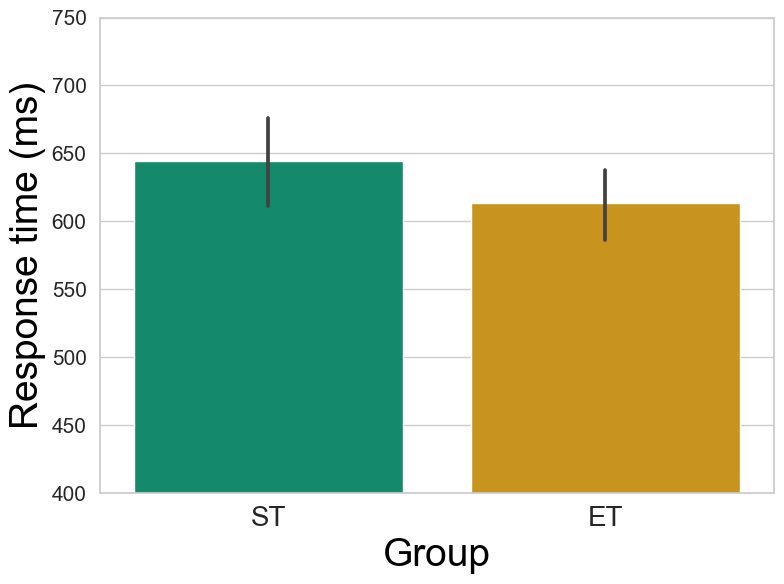

In [191]:

# Define custom colors
custom_palette = {"ET": "#E69F00", "ST": "#009E73"}
plt.figure(figsize=(8, 6))  # Set figure size

# Create the bar plot with custom colors
ax = sns.barplot(data=df_RT_Stars_cleaned, x="Group", y="MeanRT", palette=custom_palette)

# Set axis limits
plt.ylim(400, 750)

# Customize axis labels
ax.set_xlabel("Group", fontdict={'fontsize': 12, 'color': 'black'})
ax.set_ylabel("Time (ms)", fontdict={'fontsize': 12, 'color': 'black'})

# plt.title('Speeds response time - Pilot 5', fontsize=16)
plt.xlabel('Group', fontsize=28)
plt.ylabel('Response time (ms)', fontsize=28)
plt.xticks(fontsize=20)
plt.yticks(fontsize=15)
# Save the figure
plt.tight_layout()

plt.savefig("response_time_speeds.png")

# Show the plot
plt.show()


### RT for devaluation test

In [206]:
RTs_Dev = {}

for i in range(12, 15):
    if i == 13:
        continue

    RT = {'subId': {}, 'Blue': {}, 'Red': {}}

    dfs[i] = dfs[i][dfs[i].subId.isin(relevent_subIds[i])].copy()
    # dfs[i] = dfs[i][~dfs[i]['subId'].isin(outliers_Dev['subId'])]

    for idx, row in dfs[i][['subId', 'correctFirstBluePressDevtest', 'blueChoiceDev']].dropna().iterrows():
        RT_blue_row = []

        for correctFirstBluePressDev in row.correctFirstBluePressDevtest:
            choices_before_press = [
                x for x in row.blueChoiceDev
                if x < correctFirstBluePressDev
            ]

            if len(choices_before_press) > 0:
                RT_blue_row.append(correctFirstBluePressDev - choices_before_press[-1])

        if len(RT_blue_row) > 0:
            RT['subId'][idx] = row.subId
            RT['Blue'][idx] = RT_blue_row

    for idx, row in dfs[i][['subId', 'correctFirstRedPressDevtest', 'redChoiceDev']].dropna().iterrows():
        RT_red_row = []

        for correctFirstRedPressDev in row.correctFirstRedPressDevtest:
            choices_before_press = [
                x for x in row.redChoiceDev
                if x < correctFirstRedPressDev
            ]

            if len(choices_before_press) > 0:
                RT_red_row.append(correctFirstRedPressDev - choices_before_press[-1])

        if len(RT_red_row) > 0:
            RT['subId'][idx] = row.subId
            RT['Red'][idx] = RT_red_row

    RTs_Dev[i] = pd.DataFrame(RT).reset_index(drop=True)


In [207]:
def to_list(a):
    if isinstance(a, float):
        return [a]
    return a

In [211]:
mean_RTs_Dev = {}

for grp, RT in RTs_Dev.items():
    mean_RTs_Dev[grp] = pd.DataFrame({
        'subId': RT['subId'],
        'Group': 'ST' if grp == 12 else 'ET',
        'Blue': RT['Blue'].apply(lambda x: np.mean(to_list(x)) if len(to_list(x)) > 0 else np.nan),
        'Red': RT['Red'].apply(lambda x: np.mean(to_list(x)) if len(to_list(x)) > 0 else np.nan)
    })

In [213]:
# --- ST: group 12 ---
BandRST_Dev = mean_RTs_Dev[12][['subId', 'Blue']].copy()
BandRST_Dev = BandRST_Dev.rename(columns={'Blue': 'RT'})
BandRST_Dev['Condition'] = 'Dev'
BandRST_Dev['Group'] = 'ST'

BandRST_NonDev = mean_RTs_Dev[12][['subId', 'Red']].copy()
BandRST_NonDev = BandRST_NonDev.rename(columns={'Red': 'RT'})
BandRST_NonDev['Condition'] = 'nonDev'
BandRST_NonDev['Group'] = 'ST'


# --- ET: group 14 ---
BandRET_Dev = mean_RTs_Dev[14][['subId', 'Blue']].copy()
BandRET_Dev = BandRET_Dev.rename(columns={'Blue': 'RT'})
BandRET_Dev['Condition'] = 'Dev'
BandRET_Dev['Group'] = 'ET'

BandRET_NonDev = mean_RTs_Dev[14][['subId', 'Red']].copy()
BandRET_NonDev = BandRET_NonDev.rename(columns={'Red': 'RT'})
BandRET_NonDev['Condition'] = 'nonDev'
BandRET_NonDev['Group'] = 'ET'


# --- remove participants missing one condition ---
# ST: keep only participants with both Dev and nonDev RTs
st_valid_subs = set(BandRST_Dev.dropna(subset=['RT'])['subId']).intersection(
    set(BandRST_NonDev.dropna(subset=['RT'])['subId'])
)

BandRST_Dev = BandRST_Dev[BandRST_Dev['subId'].isin(st_valid_subs)]
BandRST_NonDev = BandRST_NonDev[BandRST_NonDev['subId'].isin(st_valid_subs)]


# ET: keep only participants with both Dev and nonDev RTs
et_valid_subs = set(BandRET_Dev.dropna(subset=['RT'])['subId']).intersection(
    set(BandRET_NonDev.dropna(subset=['RT'])['subId'])
)

BandRET_Dev = BandRET_Dev[BandRET_Dev['subId'].isin(et_valid_subs)]
BandRET_NonDev = BandRET_NonDev[BandRET_NonDev['subId'].isin(et_valid_subs)]


# --- long dataframe for mixed model / RM ANOVA ---
BandR_long = pd.concat(
    [BandRST_Dev, BandRST_NonDev, BandRET_Dev, BandRET_NonDev],
    ignore_index=True
).dropna(subset=['RT'])

BandR_long.head()

,subId,RT,Condition,Group
0,6645cb96d2c8fb647d0af3aa,686.880000,Dev,ST
1,6645cb96d2c8fb647d0af3af,612.047059,Dev,ST
2,6645cb96d2c8fb647d0af3ad,642.309524,Dev,ST
3,6645cb96d2c8fb647d0af3a1,651.065789,Dev,ST
4,6645cb96d2c8fb647d0af3a4,665.151899,Dev,ST
5,6645cb96d2c8fb647d0af3a9,626.534091,Dev,ST
6,6645cb96d2c8fb647d0af3b0,544.839506,Dev,ST
7,6645cb96d2c8fb647d0af3a7,391.258824,Dev,ST
8,6645cb96d2c8fb647d0af3a2,546.466667,Dev,ST
9,6645cb96d2c8fb647d0af3aa,597.641304,nonDev,ST


In [215]:
BandR_long.to_csv("df_long_dev_RT5.csv", index=False)

In [227]:
BandR_long.query("Group == 'ST' and Condition == 'nonDev'").describe()

,RT
count,9.000000
mean,568.394479
std,110.313957
min,296.809524
25%,538.829787
50%,600.386364
75%,627.413793
max,651.651163


In [219]:
# Test normality for each measure
print("Shapiro-Wilk test for 'ST-dev':", shapiro(BandRST_Dev['RT'])) 
print("Shapiro-Wilk test for 'ET':", shapiro(BandRET_Dev['RT']))
print("Shapiro-Wilk test for 'ST-nondev':", shapiro(BandRST_NonDev['RT'])) 
print("Shapiro-Wilk test for 'ET':", shapiro(BandRET_NonDev['RT']))

Shapiro-Wilk test for 'ST-dev': ShapiroResult(statistic=0.843407392501831, pvalue=0.06301279366016388)
Shapiro-Wilk test for 'ET': ShapiroResult(statistic=0.9263877272605896, pvalue=0.27135464549064636)
Shapiro-Wilk test for 'ST-nondev': ShapiroResult(statistic=0.7279460430145264, pvalue=0.0030053474474698305)
Shapiro-Wilk test for 'ET': ShapiroResult(statistic=0.8815241456031799, pvalue=0.061097122728824615)
